<a name="projet-7"></a>
# PROJET 7 : Loan Default Prediction #

<a name="contenu"></a>
## Contenu Partie N°1 ##
- [Import des données](#import-des-donnees)
- [CSV en Parquet](#csv-en-parquet)
- [Exploration et data cleaning](#exploration-et-data-cleaning)
- [EDA Automation](#EDA-Automation)
- [Data Cleaning](#Data-Cleaning)
  - [Removing exclusions](#Removing-exclusions)
  - [Missing Value Imputation](#Missing-Value-Imputation)
  - [Removing Outlier](#Removing-Outlier)
- [Correlation Analysis](#Correlation-Analysis)


<a name="Objectifs"></a>
## Objectifs ##


_**Contexte :**_
- Les institutions financières doivent évaluer le risque de défaut de paiement des prêts.
- Des prédictions précises peuvent aider à prendre des décisions de prêt.
- Le Machine learning peut analyser l'historique des données afin de prédire les défauts.

_**Objectifs:**_
- Construire un modèle prédictif de défaut de paiement basé sur le profil des emprunteurs.
- Identifier les variables clés qui influent le plus sur le risque de défaut.
- Fournir des recommendations pour atténuer les risques.

_**Origine des données**_

- "All Lending Club loan data" (2007 through current Lending Club accepted and rejected loan data)
- URL : https://www.kaggle.com/datasets/wordsforthewise/lending-club/data


_**Défis:**_
- Traitement des classes déséquilibrées: gérer les jeux de données où les cas de défaut son minoritaires.
- Feature engineering: extraire les indicateurs les plus pertinents du profil des candidats.
- Interprétabilité du modèle: transformer les résultats techniques enleviers d'action concrets.


In [1]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy.stats as sps
import seaborn as sns

In [ ]:
# from datetime import datetime
# start_time = datetime.now()

# import tensorflow as tf
# from matplotlib import rcParams

# %matplotlib inline
# # figure size in inches
# rcParams['figure.figsize'] = 8,6


# # Plotly visualizations
# from plotly import tools
# # import chart_studio.plotly as py
# import plotly.figure_factory as ff
# import plotly.graph_objs as go
# from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

# import plotly.offline as pyo
# import plotly.express as px
# init_notebook_mode(connected=True)

# # For oversampling Library (Dealing with Imbalanced Datasets)
# from imblearn.over_sampling import SMOTE
# from collections import Counter
# from sklearn.preprocessing import LabelEncoder

# from sklearn.pipeline import make_pipeline
# from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

# from imblearn.under_sampling import NearMiss
# from imblearn.metrics import classification_report_imbalanced

# import math
# import itertools as it
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS
# import warnings
# warnings.filterwarnings("ignore")

# # Classifier
# from sklearn.svm import SVC

# # Other machine learning tools

# from sklearn.feature_selection import RFECV
# import scipy.stats as sps

# print('LOADING DURATION: ', datetime.now() - start_time)

# pd.set_option('display.max_rows', 20)
# pd.set_option('display.max_columns', 20)

<a name="import-des-donnees"></a>
## [Import des données](#contenu) ##


In [2]:
df = pd.read_csv("DATA/accepted_2007_to_2018Q4.csv")

C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\166737960.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("DATA/accepted_2007_to_2018Q4.csv")


In [3]:
# Correction du format de 'id'

df['id'] = df['id'].astype(str)

In [4]:
# Conversion de la colonne issue_d en format datetime

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

<a name="csv-en-parquet"></a>
## [CSV en Parquet](#contenu) ## 


In [5]:
# Sauvegarder en parquet

df.to_parquet("DATA/accepted_2007_to_2018Q4.parquet")

print("Conversion terminée !")

Conversion terminée !


In [6]:
# Nettoyer la mémoire vive (RAM)

# 1. Supprimer le gros DataFrame chargé depuis le CSV
if 'df' in locals():
    del df

# 2. Forcer la libération de la mémoire
gc.collect()

# 3. Charger le nouveau fichier Parquet (beaucoup plus léger)
df = pd.read_parquet("DATA/accepted_2007_to_2018Q4.parquet")

print("Données chargées depuis le format Parquet !")
print(f"Dimensions du dataset : {df.shape}")

Données chargées depuis le format Parquet !
Dimensions du dataset : (2260701, 151)


In [7]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,...,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN


### Notre base de données contient 2260701 lignes et 151 colonnes 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: datetime64[ns](1), float64(113), object(37)
memory usage: 2.5+ GB


In [9]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2260668,2.258957e+06,2.260639e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,2016-05-02 18:48:08.652733696,1.882420e+01,3.068792e-01,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,2007-06-01 00:00:00,-1.000000e+00,0.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,2015-04-01 00:00:00,1.189000e+01,0.000000e+00,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,2016-07-01 00:00:00,1.784000e+01,0.000000e+00,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2017-11-01 00:00:00,2.449000e+01,0.000000e+00,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,2018-12-01 00:00:00,9.990000e+02,5.800000e+01,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,NaN,1.418333e+01,8.672303e-01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980


### En observant le count on remarque qu'il y'a des variables qui ont de grands nombres de valeurs manquantes.

In [10]:
## Déterminons le nombre de valeurs manquantes par colonnes
df.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [11]:
## pourcentage de valeurs manquantes par colonne
(df.isnull().mean()*100)

id                         0.00000
member_id                100.00000
loan_amnt                  0.00146
funded_amnt                0.00146
funded_amnt_inv            0.00146
                           ...    
settlement_status         98.48516
settlement_date           98.48516
settlement_amount         98.48516
settlement_percentage     98.48516
settlement_term           98.48516
Length: 151, dtype: float64

### On remarque qu'il y'a des colonnes qui n'ont pratiquement pas de valeurs

In [12]:
## les variables ayant plus de 80% de valeurs manquantes
missing_values_percentage= df.isna().mean()[df.isna().mean() >= 0.8]

In [13]:
missing_values_percentage

member_id                                     1.000000
desc                                          0.944236
mths_since_last_record                        0.841131
annual_inc_joint                              0.946605
dti_joint                                     0.946607
verification_status_joint                     0.948808
revol_bal_joint                               0.952218
sec_app_fico_range_low                        0.952218
sec_app_fico_range_high                       0.952218
sec_app_earliest_cr_line                      0.952218
sec_app_inq_last_6mths                        0.952218
sec_app_mort_acc                              0.952218
sec_app_open_acc                              0.952218
sec_app_revol_util                            0.953030
sec_app_open_act_il                           0.952218
sec_app_num_rev_accts                         0.952218
sec_app_chargeoff_within_12_mths              0.952218
sec_app_collections_12_mths_ex_med            0.952218
sec_app_mt

In [14]:
missing_values_percentage.count()

np.int64(39)

### Il y'a donc 39 variables qui ont plus de 80% de valeurs manquantes


In [15]:
## L'état des prêts.
stats_pret = pd.concat([df['loan_status'].value_counts(), 
                df['loan_status'].value_counts(normalize=True) * 100], 
               axis=1, keys=['Nombre', 'Pourcentage (%)'])

print(stats_pret)

                                                     Nombre  Pourcentage (%)
loan_status                                                                 
Fully Paid                                          1076751        47.629771
Current                                              878317        38.852100
Charged Off                                          268559        11.879630
Late (31-120 days)                                    21467         0.949587
In Grace Period                                        8436         0.373164
Late (16-30 days)                                      4349         0.192377
Does not meet the credit policy. Status:Fully Paid     1988         0.087939
Does not meet the credit policy. Status:Charged...      761         0.033663
Default                                                  40         0.001769


### Nous avons donc un bon apperçu des prêts déjà remboursés et ceux en cours qui n'ont aucun retard, et aussi la part des prêts qui ont fait défauts

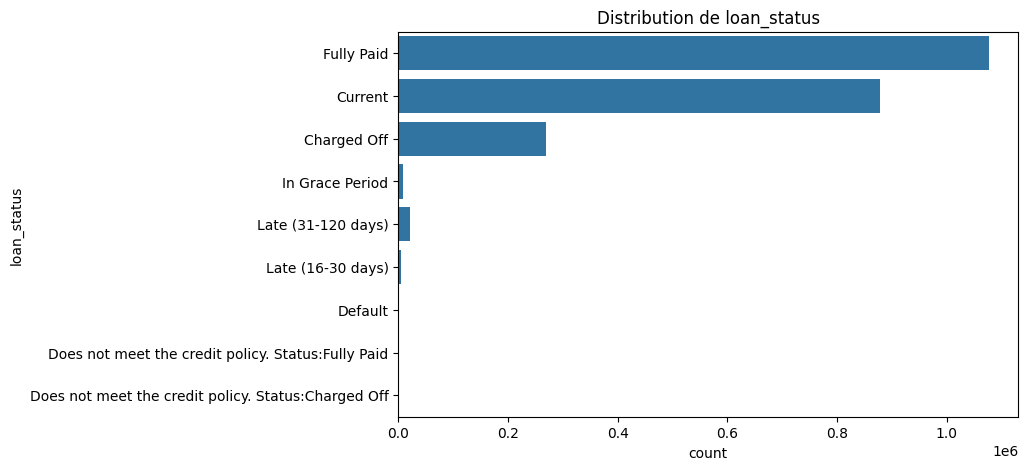

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(y='loan_status', data=df)
plt.title("Distribution de loan_status")
plt.show()

In [17]:
num_vars = df.select_dtypes(include=['int64','float64']).columns
cat_vars = df.select_dtypes(include=['object']).columns

print("Variables numériques :", len(num_vars))
print("Variables catégorielles :", len(cat_vars))

Variables numériques : 113
Variables catégorielles : 37


## Notre base contient donc 113 variables numériques et 37 varibles catégorielles

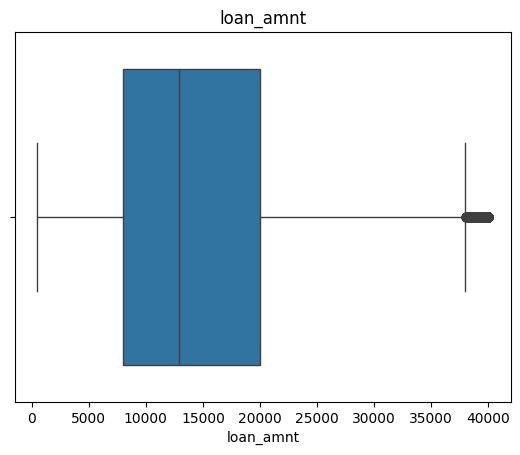

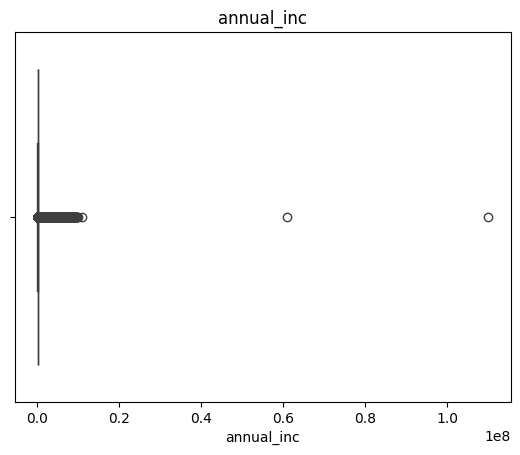

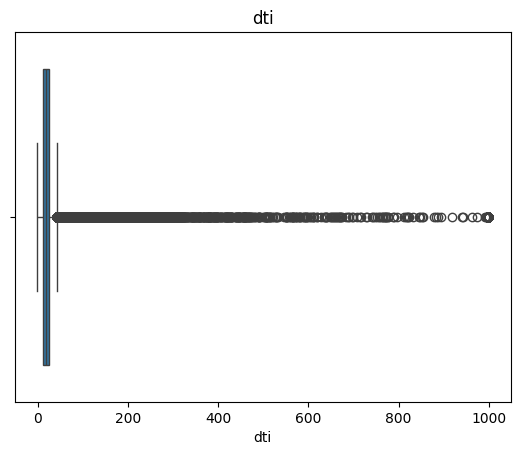

In [18]:
for col in ['loan_amnt','annual_inc','dti']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<a name="etude-loan-status-et-issue-d"></a>
## [Etude des colonnes "loan status" et "issue_d"](#contenu) ## 


### Pour une meilleure analyse , nous utiliserons un échantillon aléatoire

In [19]:
df_bases= df.sample(n=100000, random_state=42)


In [21]:
# Filtre pour ne garder que les lignes "Current"
current_loans = df_bases[df_bases['loan_status'] == 'Current']

# Calcule des occurrences de issue_d sur ce sous-ensemble
counts = current_loans['issue_d'].value_counts().sort_index(ascending=False)

print("Aperçu des occurrences :")
print(counts)

Aperçu des occurrences :
issue_d
2018-12-01    1660
2018-11-01    1833
2018-10-01    1952
2018-09-01    1613
2018-08-01    1860
2018-07-01    1659
2018-06-01    1582
2018-05-01    1678
2018-04-01    1495
2018-03-01    1338
2018-02-01    1110
2018-01-01    1177
2017-12-01    1147
2017-11-01    1332
2017-10-01    1062
2017-09-01    1048
2017-08-01    1177
2017-07-01    1011
2017-06-01     991
2017-05-01     824
2017-04-01     739
2017-03-01     850
2017-02-01     627
2017-01-01     649
2016-12-01     710
2016-11-01     586
2016-10-01     572
2016-09-01     458
2016-08-01     594
2016-07-01     549
2016-06-01     539
2016-05-01     443
2016-04-01     558
2016-03-01     569
2016-02-01     179
2016-01-01     185
2015-12-01     232
2015-11-01     217
2015-10-01     252
2015-09-01     156
2015-08-01     177
2015-07-01     210
2015-06-01     113
2015-05-01     153
2015-04-01     174
2015-03-01      98
2015-02-01      96
2015-01-01     117
2014-12-01      41
2014-11-01      87
2014-10-01     11

In [22]:
# Séparation en deux groupes en utilisant une simple comparaison de chaînes de caractères
mask_recent = counts.index >= '2017-01'
mask_old = counts.index <= '2016-12'

# Calcule de la somme pour chaque groupe
count_2017_2018 = counts[mask_recent].sum()
count_2016_and_before = counts[mask_old].sum()

print(f"Occurrences de 'Current' (2017-01 à 2018-12) : {count_2017_2018}")
print(f"Occurrences de 'Current' (2016-12 et inférieur) : {count_2016_and_before}")

Occurrences de 'Current' (2017-01 à 2018-12) : 30414
Occurrences de 'Current' (2016-12 et inférieur) : 8473


In [27]:
# Retrait des "current" trop récent pour tirer des conclusions 
lignes_a_supprimer = (df_bases['loan_status'] == 'Current') & (df_bases['issue_d'] >= '2017-01-01')

# On met à jour le dataframe
df = df_bases[~lignes_a_supprimer].copy()

# Vérification
print(f"Nombre de lignes restantes dans le dataframe après nettoyage : {len(df)}")

Nombre de lignes restantes dans le dataframe après nettoyage : 69586


<a name="exploration-et-data-cleaning"></a>
## [Exploration et data cleaning](#contenu) ##


In [31]:
df.shape 

(69586, 151)

In [29]:
# Aperçu des 5 premières lignes

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
392949,39651438,NaN,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1273506,16411620,NaN,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
324024,45122316,NaN,4000.0,4000.0,4000.0,36 months,6.68,122.93,A,A3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2066630,125356772,NaN,6025.0,6025.0,6025.0,36 months,10.91,197.00,B,B4,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1975547,88273234,NaN,20000.0,20000.0,20000.0,36 months,9.49,640.57,B,B2,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN


In [30]:
# Aperçu des 5 dernières lignes

df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1217099,23933451,NaN,10000.0,10000.0,10000.0,36 months,6.03,304.36,A,A1,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
32451,66490311,NaN,1200.0,1200.0,1200.0,36 months,9.76,38.59,B,B3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
363389,41368988,NaN,25200.0,25200.0,25200.0,36 months,16.99,898.33,D,D3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1908460,1513211,NaN,10000.0,10000.0,10000.0,36 months,15.31,348.18,C,C2,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
347653,43165428,NaN,12000.0,12000.0,12000.0,36 months,6.39,367.19,A,A2,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN


<a name="Retrait des lignes de totalisation"></a>
### Retrait des lignes de totalisation ###


In [32]:
# On cherche les lignes dont l'id contient "Total" (insensible à la casse)
lignes_total = df[df['id'].str.contains("Total", case=False, na=False)]

print(f"Nombre de lignes de totaux explicites détectées : {len(lignes_total)}")
print("\nContenu de la colonne 'id' pour ces lignes :")
print(lignes_total['id'].unique())

Nombre de lignes de totaux explicites détectées : 4

Contenu de la colonne 'id' pour ces lignes :
['Total amount funded in policy code 2: 564202131'
 'Total amount funded in policy code 1: 1741781700'
 'Total amount funded in policy code 1: 2087217200'
 'Total amount funded in policy code 2: 823319310']


In [33]:
# On ne garde que les lignes qui ne contiennent PAS "Total" dans l'id
df = df[~df['id'].str.contains("Total", case=False, na=False)]

print(f"Lignes de totaux purgées. Nouvelle taille : {len(df)}")

Lignes de totaux purgées. Nouvelle taille : 69582


In [34]:
# Compte des lignes où loan_amnt est manquant
nb_null_loan = df['loan_amnt'].isnull().sum()

print(f"Nombre de lignes parasites (loan_amnt nul) : {nb_null_loan}")

# Visualiser ces lignes pour confirmer qu'il s'agit bien de totaux
print("\nAperçu des colonnes 'id' de ces lignes :")
print(df[df['loan_amnt'].isnull()]['id'].unique())

Nombre de lignes parasites (loan_amnt nul) : 0

Aperçu des colonnes 'id' de ces lignes :
[]


In [35]:
# Suppression des lignes où loan_amnt est NaN
df = df.dropna(subset=['loan_amnt'])

# Vérification de la nouvelle taille du dataset
print(f"Nettoyage terminé. Nouvelles dimensions : {df.shape}")

# Vérification visuelle de la fin du fichier
df.tail()

Nettoyage terminé. Nouvelles dimensions : (69582, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1217099,23933451,NaN,10000.0,10000.0,10000.0,36 months,6.03,304.36,A,A1,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
32451,66490311,NaN,1200.0,1200.0,1200.0,36 months,9.76,38.59,B,B3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
363389,41368988,NaN,25200.0,25200.0,25200.0,36 months,16.99,898.33,D,D3,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1908460,1513211,NaN,10000.0,10000.0,10000.0,36 months,15.31,348.18,C,C2,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
347653,43165428,NaN,12000.0,12000.0,12000.0,36 months,6.39,367.19,A,A2,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN


<a name="Vérification des lignes en doublon"></a>
### Vérification des lignes en doublon ###


In [36]:
# Compter le nombre total de lignes 100% identiques
nb_doublons = df.duplicated().sum()

print(f"Nombre de lignes en doublon détectées : {nb_doublons}")

# Aperçu de ces doublons :
if nb_doublons > 0:
    print("\nAperçu des lignes dupliquées :")
    display(df[df.duplicated()].head())

Nombre de lignes en doublon détectées : 0


<a name="Vérification des colonnes entièrement à Null"></a>
### Vérification des colonnes entièrement à Null ###


In [37]:
# Liste des colonnes 100% nulles

all_null_cols = df.columns[df.isnull().all()].tolist()

if len(all_null_cols) > 0:
    print(f"Il y a {len(all_null_cols)} colonnes entièrement vides :")
    print(all_null_cols)
else:
    print("Aucune colonne n'est entièrement vide.")

Il y a 1 colonnes entièrement vides :
['member_id']


In [38]:
# Suppression de la colonne member_id

df = df.drop(columns=['member_id'])
print("La colonne 'member_id' a été supprimée.")

La colonne 'member_id' a été supprimée.


<a name="Suppression des colonnes Hardship, Settlement et historique"></a>
### Suppression des colonnes "Hardship", "Settlement" et historique du remboursement ###


In [42]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
orig_projected_additional_accrued_interest    69243
sec_app_mths_since_last_major_derog           69218
hardship_last_payment_amount                  69139
payment_plan_start_date                       69139
hardship_reason                               69139
hardship_type                                 69139
hardship_payoff_balance_amount                69139
hardship_status                               69139
hardship_start_date                           69139
hardship_amount                               69139
hardship_dpd                                  69139
hardship_loan_status                          69139
hardship_length                               69139
hardship_end_date                             69139
deferral_term                                 69139
sec_app_revol_util                            68618
sec_app_chargeoff_within_12_mths              68595
revol_bal_joint                               68595
sec_app_open_acc     

**Suppression des colonnes "Hardship" (Plans de difficultés financières)**

Ces colonnes concernent les emprunteurs qui ont rencontré de graves problèmes financiers (perte d'emploi, maladie) et qui ont négocié un plan de sauvetage temporaire ("Hardship plan") avec Lending Club :

 *   hardship_reason : La cause de la difficulté (chômage, etc.).
 *   hardship_type : Le type de plan mis en place.
 *   hardship_status : Le statut du plan (actif, terminé, annulé).
 *   hardship_amount : Le montant de la mensualité pendant le plan.
 *   hardship_start_date / hardship_end_date : Dates de début et de fin du plan.
 *   hardship_length : La durée du plan en mois.
 *   hardship_dpd : Nombre de jours de retard de paiement (Days Past Due) au moment du plan.
 *   hardship_loan_status : Le statut du prêt pendant le plan.
 *   hardship_payoff_balance_amount : Le montant total restant à payer à l'issue du plan.
 *   hardship_last_payment_amount : Le dernier paiement effectué sous ce régime.
 *   payment_plan_start_date : Le jour où le plan a officiellement commencé.
 *   deferral_term : Le nombre de mois pendant lesquels le paiement a été repoussé.
 *   orig_projected_additional_accrued_interest : Les intérêts supplémentaires qui vont s'accumuler à cause de ce plan.

**Objectif de la suppression : éviter le Data Leakage** 

Ces informations n'existent que parce que l'emprunteur a déjà cessé de payer normalement. 
Or, le but du Machine Learning est de prédire le défaut au moment où le prêt est accordé, donc moment où toutes ces colonnes sont inexistantes.

In [44]:
# Liste exhaustive des colonnes "Hardship"
cols_hardship = [
    'orig_projected_additional_accrued_interest',
    'hardship_reason', 
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 
    'payment_plan_start_date',
    'hardship_type', 
    'hardship_status', 
    'hardship_start_date',
    'deferral_term', 
    'hardship_amount', 
    'hardship_dpd',
    'hardship_loan_status', 
    'hardship_length', 
    'hardship_end_date',
    'hardship_flag'  
]

# Suppression des colonnes (errors='ignore' évite un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_hardship, errors='ignore')

print("Les colonnes 'Hardship' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'Hardship' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (69582, 135)


**Suppression des colonnes "Settlement" (Règlements de dettes)**

Ces colonnes s'activent lorsqu'un prêt a définitivement fait défaut ("Charged Off") et que le service de recouvrement négocie avec l'emprunteur pour récupérer au moins une partie de l'argent (par exemple, solder la dette pour 40% du montant restant) :

 *   settlement_status : Le statut de l'accord de règlement (ex: complet, rompu).
 *   settlement_date : La date à laquelle le recouvrement a accepté le règlement.
 *   settlement_amount : Le montant final convenu pour clore la dette.
 *   settlement_percentage : Le pourcentage de la dette initiale que représente le règlement.
 *   settlement_term : Le nombre de mois accordés pour payer ce règlement.
 *   debt_settlement_flag_date : La date à laquelle le dossier a été marqué comme "en cours de règlement".


**Objectif de la suppression : éviter le Data Leakage** 

Exactement comme pour le groupe "Hardship", un modèle qui voit un montant dans settlement_amount saura à 100% que le prêt est mauvais, rendant la prédiction inutile et biaisée.


In [45]:
# Liste exhaustive des colonnes "Settlement"
cols_settlement = [
    'settlement_status',
    'debt_settlement_flag_date',
    'settlement_term',
    'settlement_percentage',
    'settlement_date',
    'settlement_amount',
    'debt_settlement_flag'  
]

# Suppression des colonnes (errors='ignore' évite un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_settlement, errors='ignore')

print("Les colonnes 'Settlement' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'Settlement' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (69582, 128)


**Suppression des colonnes liée à l'historique de remboursement du prêt et son état actuel**

 Ces variables décrivent l'historique de remboursement du prêt et son état actuel :

 *   out_prncp / out_prncp_inv : Capital restant dû (principal) sur le montant total financé / sur la part financée par les investisseurs.
 *   total_pymnt / total_pymnt_inv : Total des paiements reçus à ce jour pour le montant total financé / pour la part des investisseurs.
 *   total_rec_prncp : Capital (principal) remboursé par l'emprunteur à ce jour.
 *   total_rec_int : Intérêts remboursés par l'emprunteur à ce jour.
 *   total_rec_late_fee : Frais ou pénalités de retard perçus à ce jour.
 *   recoveries : Montants récupérés après que le prêt a été déclaré en perte (procédure de recouvrement post "charge-off").
 *   collection_recovery_fee : Frais de gestion facturés par les agences de recouvrement pour récupérer les fonds.
 *   last_pymnt_amnt : Montant du tout dernier paiement total reçu.
 *   last_pymnt_d : Date (mois) à laquelle le dernier paiement a été enregistré.
 *   last_credit_pull_d : Date la plus récente à laquelle le prêteur a consulté le dossier de crédit de l'emprunteur.
 *   next_pymnt_d : Date du prochain paiement.


**Objectif de la suppression : éviter le Data Leakage** 

Dans un projet de prédiction de défaut de paiement, l'objectif est de déterminer si un emprunteur va faire défaut au moment où il demande son prêt. Or, ces informations (paiements reçus, reliquat du capital, frais de retard) ne sont connues qu'après que le prêt a été accordé.

In [46]:
# Liste des colonnes de "Data Leakage" (données futures ou liées au comportement de remboursement)
cols_leakage = [
    'out_prncp', 
    'out_prncp_inv', 
    'total_pymnt', 
    'total_pymnt_inv',
    'total_rec_prncp', 
    'total_rec_int', 
    'total_rec_late_fee',
    'recoveries', 
    'collection_recovery_fee', 
    'last_pymnt_amnt',
    'last_pymnt_d', 
    'last_credit_pull_d',
    'next_pymnt_d'
]

# Suppression des colonnes
df = df.drop(columns=cols_leakage, errors='ignore')

print("Les colonnes de 'Data Leakage' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de 'Data Leakage' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (69582, 115)


**Suppression de la colonne "issue_d"**

Ce n'est techniquement pas du Data Leakage.
L'objectif est de prédire si un emprunteur va faire défaut avant de lui accorder le prêt.
Or, au moment où le client fait sa demande, la date du jour (qui deviendra le mois et l'année de issue_d) est connue.

Mais si l'on donne l'année "2014" ou "2015" à un algorithme, il risque d'apprendre des règles du type : "les prêts de 2014 ont eu beaucoup de défauts, donc l'année 2014 est un risque".

Le problème ? Quand vous déploierez ce modèle en production en 2025 ou 2026, l'algorithme ne saura pas comment interpréter ces nouvelles années qu'il n'a jamais vues pendant son entraînement. Il va donc perdre en performance.

Conserver issue_d dans les features risque d'apporter plus de problèmes (overfitting temporel) que de solutions. 


In [47]:
# Suppression des colonnes
cols_leakage = ['issue_d']
df = df.drop(columns=cols_leakage, errors='ignore')

print("Les colonnes de 'Data Leakage' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de 'Data Leakage' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (69582, 114)


<a name="Suppression des lignes des prêts conjoints"></a>
### Suppression des lignes des "prêts conjoints" ###


In [48]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
sec_app_mths_since_last_major_derog    69218
sec_app_revol_util                     68618
sec_app_num_rev_accts                  68595
sec_app_open_act_il                    68595
sec_app_chargeoff_within_12_mths       68595
revol_bal_joint                        68595
sec_app_open_acc                       68595
sec_app_fico_range_low                 68595
sec_app_fico_range_high                68595
sec_app_earliest_cr_line               68595
sec_app_mort_acc                       68595
sec_app_collections_12_mths_ex_med     68595
sec_app_inq_last_6mths                 68595
verification_status_joint              68113
dti_joint                              68097
annual_inc_joint                       68097
desc                                   64063
mths_since_last_record                 57734
mths_since_recent_bc_dlq               52831
mths_since_last_major_derog            51066
dtype: int64


**Suppression des lignes avec un "Co-emprunteur" (sec_app_... et ..._joint)**

Des colonnes (comme annual_inc_joint ou sec_app_fico_range_low) correspondent aux informations d'un second demandeur lorsque le prêt est fait à deux (demande conjointe).

Or, les prêts conjoints (à deux emprunteurs) ont une dynamique de risque très différente des prêts individuels (les revenus et les dettes sont cumulés). Mélanger les deux dans un même modèle peut embrouiller l'algorithme. 

Dans la mesure où ces prêts conjoints ne représentent que quelques pourcents du dataset, il semble préférable de les retirer.

In [49]:
# Voir combien il y a de prêts de chaque type
print("Répartition des types de prêts avant filtrage :")
print(df['application_type'].value_counts())

# Ne conserver que les prêts individuels
df = df[df['application_type'] == 'Individual']

# Supprimer la colonne 'application_type' devenue inutile
df = df.drop(columns=['application_type'])

print(f"\nPrêts conjoints supprimés ! Nouvelles dimensions : {df.shape}")

Répartition des types de prêts avant filtrage :
application_type
Individual    68097
Joint App      1485
Name: count, dtype: int64

Prêts conjoints supprimés ! Nouvelles dimensions : (68097, 113)


**Suppression des colonnes ne contenant aucune donnée**


In [50]:
# Liste des colonnes 100% nulles

all_null_cols = df.columns[df.isnull().all()].tolist()

if len(all_null_cols) > 0:
    print(f"Il y a {len(all_null_cols)} colonnes entièrement vides :")
    print(all_null_cols)
else:
    print("Aucune colonne n'est entièrement vide.")

Il y a 16 colonnes entièrement vides :
['annual_inc_joint', 'dti_joint', 'verification_status_joint', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']


In [51]:
# On supprime les colonnes qui sont 100% vides
df = df.dropna(axis=1, how='all')
print(f"Purge terminée ! Nouvelles dimensions du dataset : {df.shape}")

Purge terminée ! Nouvelles dimensions du dataset : (68097, 97)


### Visualisation après la purge

In [55]:
# Affiche la liste brute
print(df.columns.tolist())

['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'pymnt_plan', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 

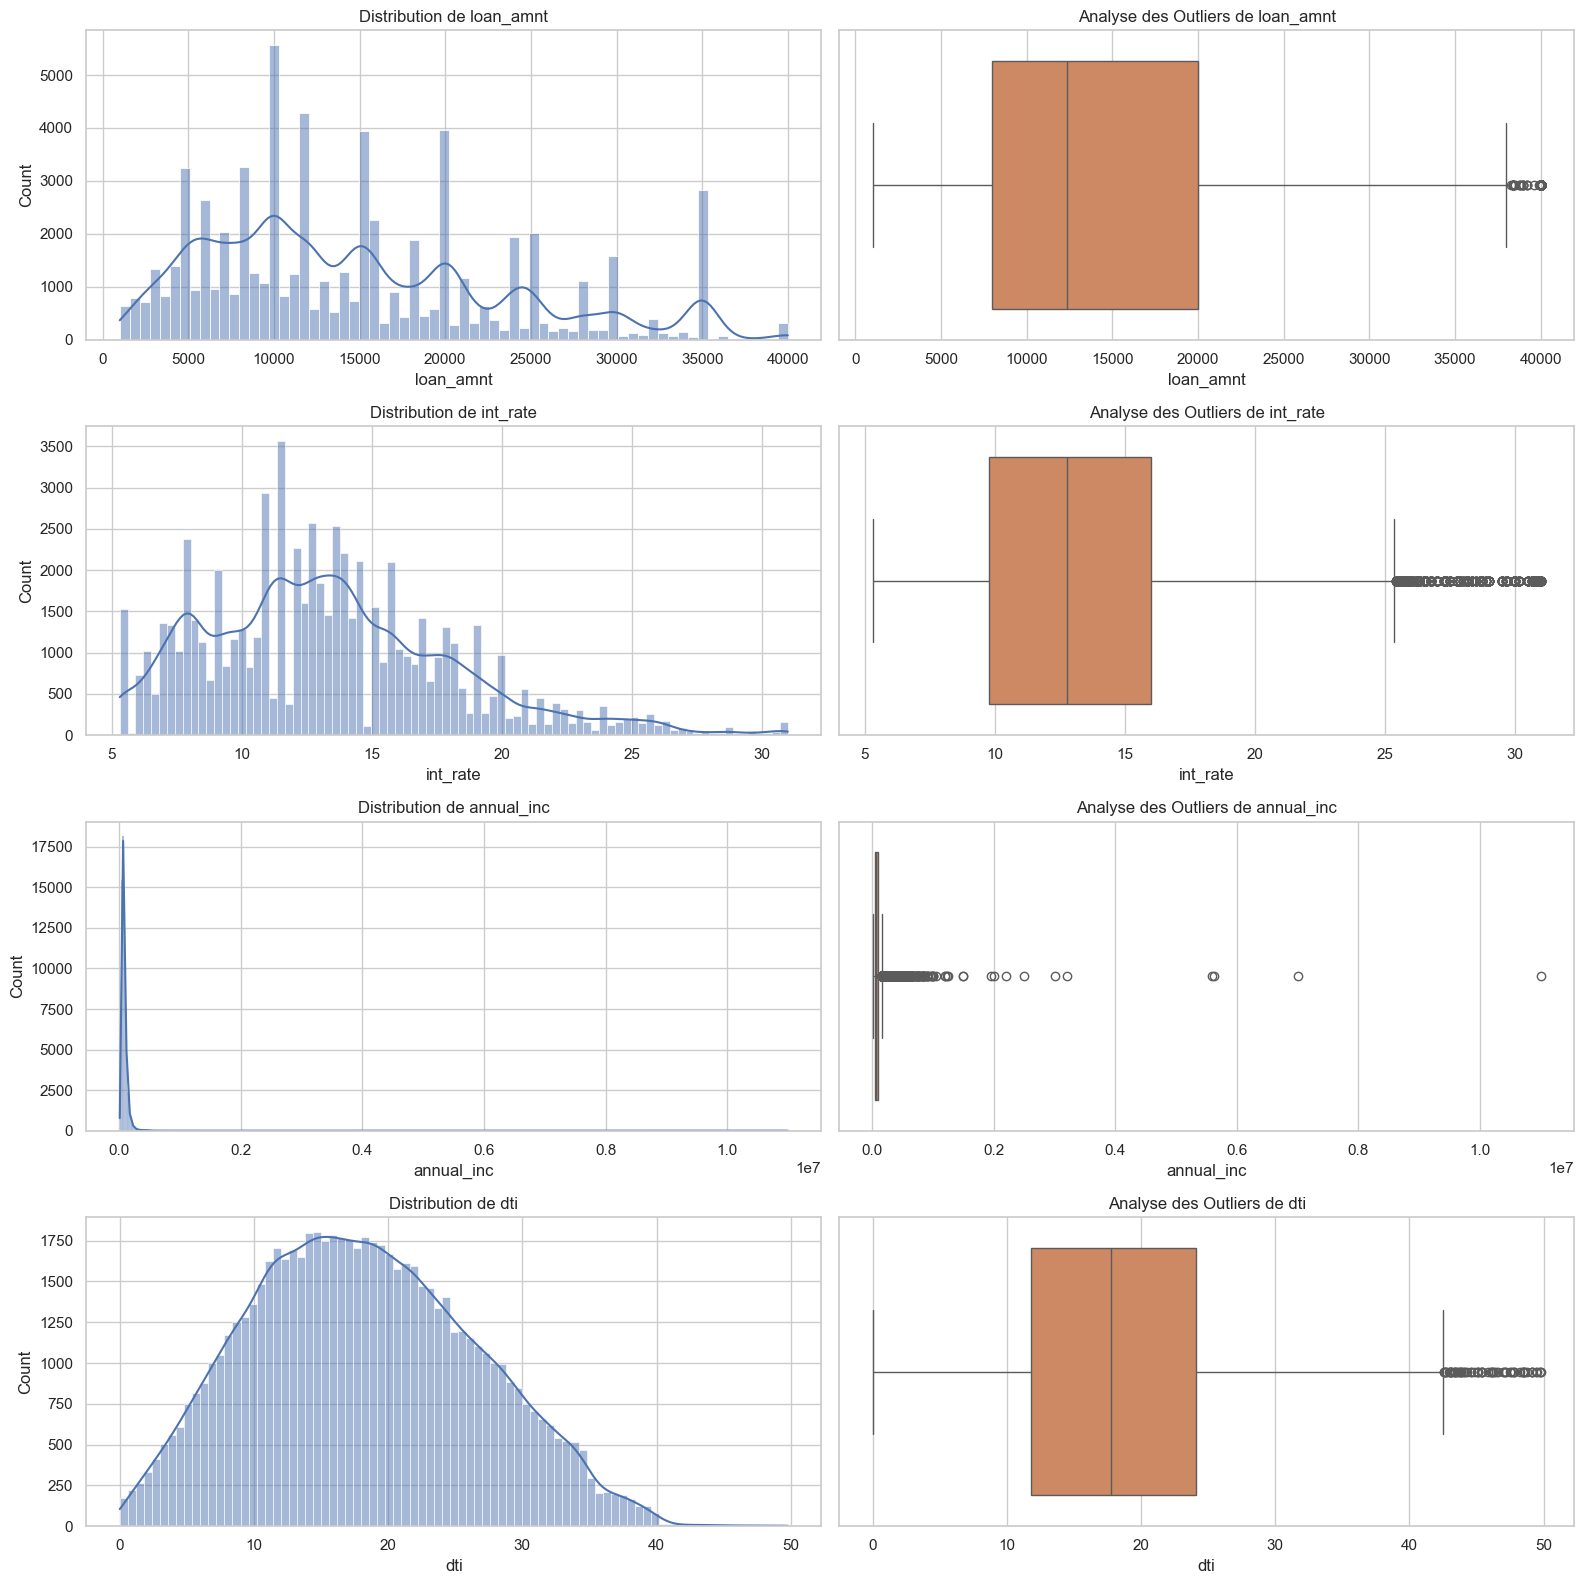

C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\2831392706.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\2831392706.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\2831392706.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\28313

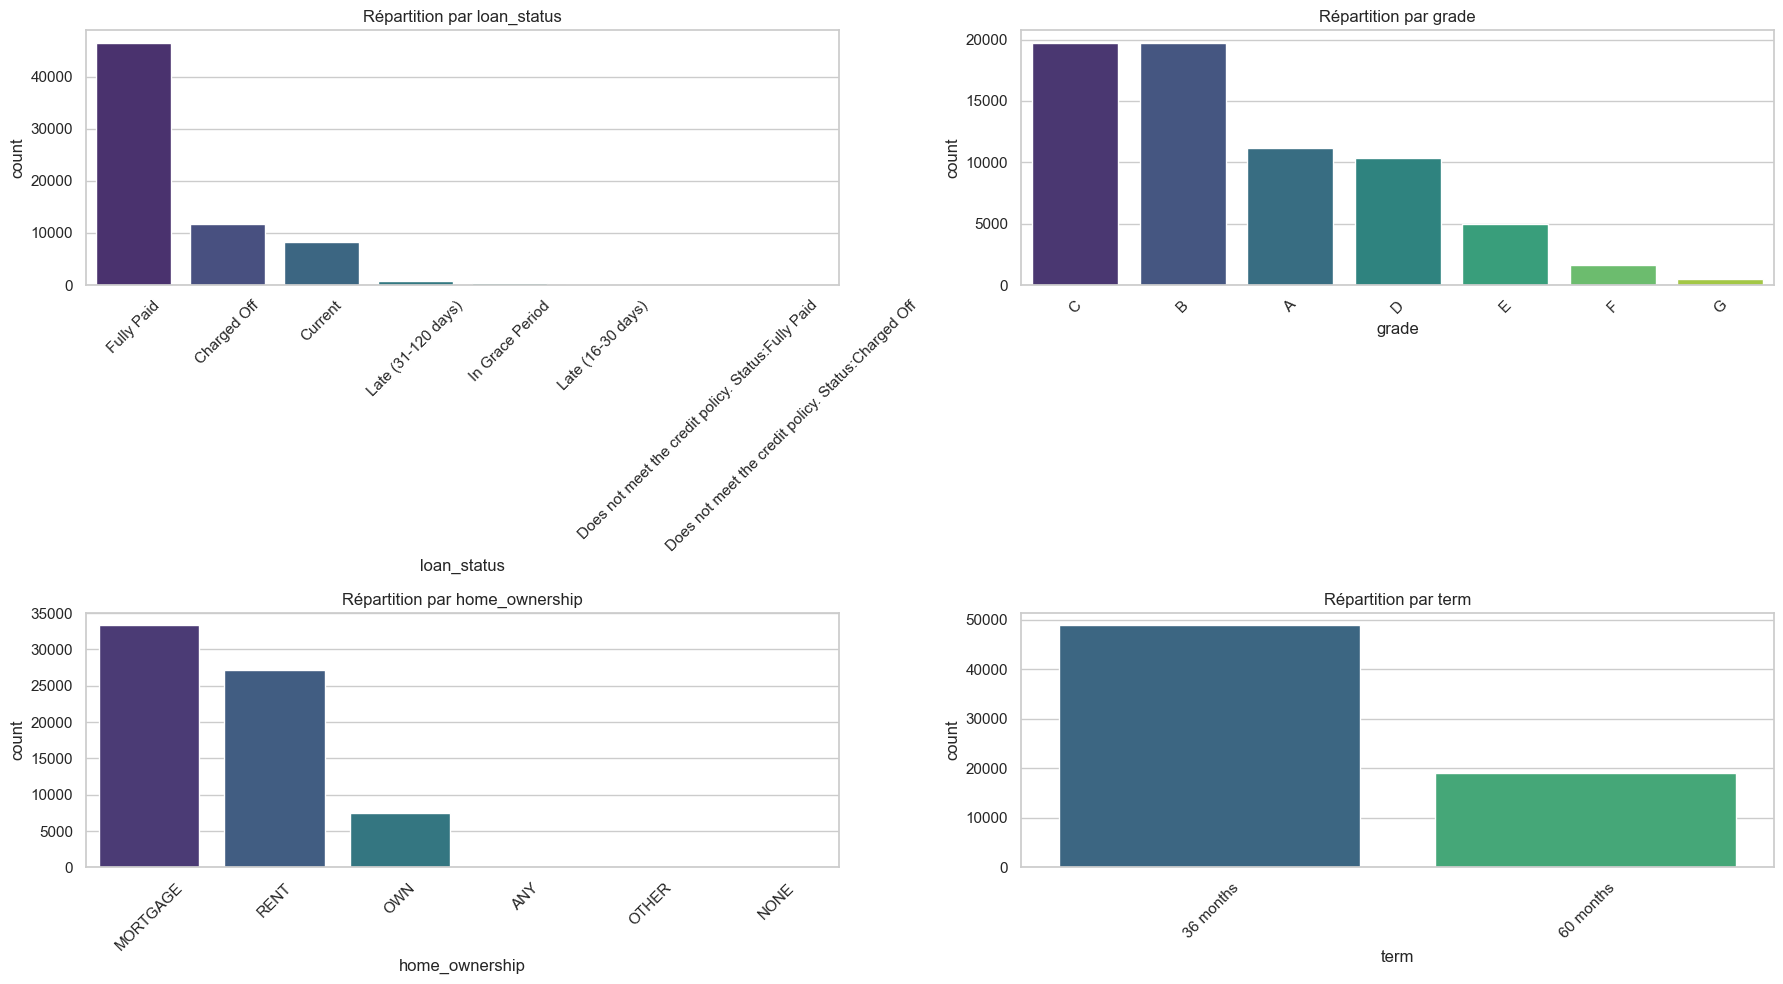

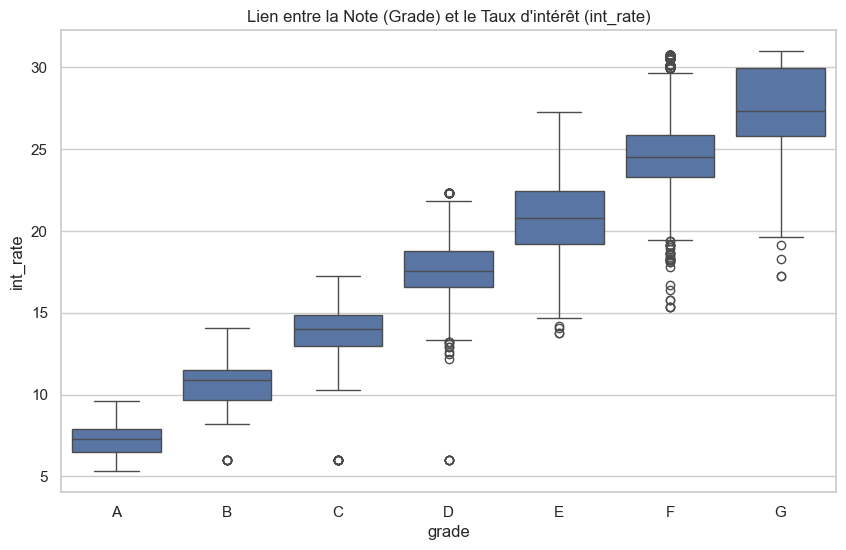

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit les variables les plus pertinentes par catégorie
# 1. Le Prêt : loan_amnt, int_rate, installment
# 2. Le Risque : grade, fico_range_high
# 3. L'Emprunteur : annual_inc, dti, home_ownership
# 4. Historique : open_acc, revol_util

sns.set_theme(style="whitegrid")

# --- VISUALISATION 1 : Les Variables Numériques (Distributions & Outliers) ---
num_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']

fig, axes = plt.subplots(len(num_features), 2, figsize=(16, 4 * len(num_features)))

for i, col in enumerate(num_features):
    # Distribution
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f'Distribution de {col}')
    
    # Outliers
    sns.boxplot(x=df[col], ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f'Analyse des Outliers de {col}')

plt.tight_layout()
plt.show()

# --- VISUALISATION 2 : Les Variables Catégorielles (Segmentation) ---
cat_features = ['loan_status', 'grade', 'home_ownership', 'term']

plt.figure(figsize=(18, 10))
for i, col in enumerate(cat_features):
    plt.subplot(2, 2, i+1)
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="viridis")
    plt.title(f'Répartition par {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- VISUALISATION 3 : Relation Risque vs Taux ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='grade', y='int_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title("Lien entre la Note (Grade) et le Taux d'intérêt (int_rate)")
plt.show()

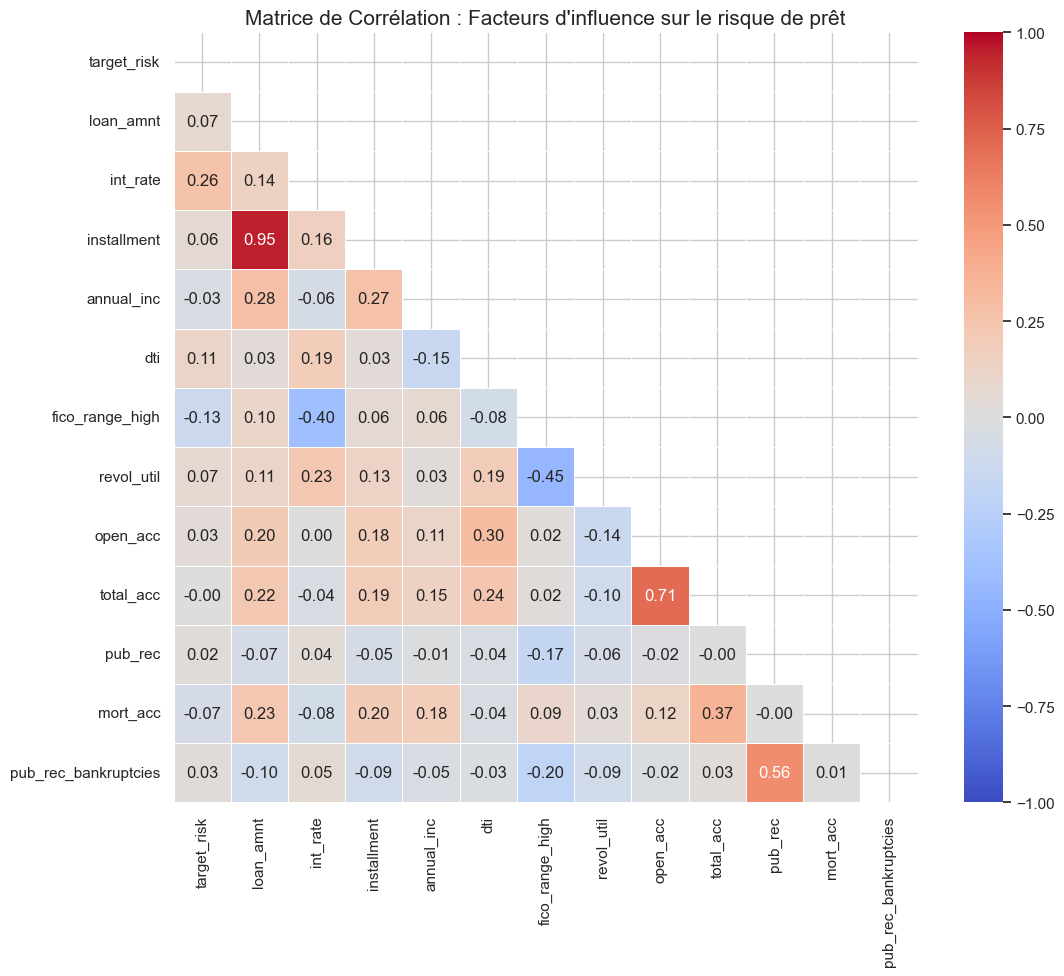

In [57]:

# 1. On prépare une version numérique de la cible pour la voir dans la matrice
# On considère que 'Charged Off' = 1 (Risque) et 'Fully Paid' = 0
df['target_risk'] = df['loan_status'].map({'Charged Off': 1, 'Fully Paid': 0})

# 2. Sélection des variables numériques pertinentes (parmi tes 92)
cols_for_corr = [
    'target_risk', 'loan_amnt', 'int_rate', 'installment', 'annual_inc', 
    'dti', 'fico_range_high', 'revol_util', 'open_acc', 'total_acc', 
    'pub_rec', 'mort_acc', 'pub_rec_bankruptcies'
]

# 3. Calcul de la matrice
corr_matrix = df[cols_for_corr].corr()

# 4. Affichage avec un "Mask" pour ne voir que la moitié (plus lisible)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0,
            linewidths=.5)

plt.title('Matrice de Corrélation : Facteurs d\'influence sur le risque de prêt', fontsize=15)
plt.show()

### On peut donc voir la corrélation entre les différentes colonnes

In [52]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
desc                              62578
mths_since_last_record            56515
mths_since_recent_bc_dlq          51680
mths_since_last_major_derog       49980
mths_since_recent_revol_delinq    44998
il_util                           42341
mths_since_rcnt_il                39124
all_util                          38328
open_acc_6m                       38327
open_il_24m                       38327
open_il_12m                       38327
open_rv_12m                       38327
total_bal_il                      38327
open_rv_24m                       38327
max_bal_bc                        38327
inq_fi                            38327
total_cu_tl                       38327
open_act_il                       38327
inq_last_12m                      38327
mths_since_last_delinq            34021
dtype: int64


**Colonnes contenant du texte libre ou des données non structurées**

 *   emp_title (Titre du poste) : Le nom du poste ou métier renseigné librement par l'emprunteur lors de sa demande. Étant un champ de texte libre, il contient d'innombrables fautes de frappe, abréviations et variantes pour un même métier. En l'éat, il y a trop de valeurs uniques. Sans un traitement lourd, cette variable va faire "planter" ou sur-apprendre les modèles.

 *   desc (Description du prêt) : Un paragraphe rédigé par l'emprunteur pour expliquer pourquoi il a besoin de ce prêt. C'est du texte pur. Bien qu'il puisse contenir du sens, l'extraire demanderait des techniques de traitement qui sortent du cadre d'une modélisation standard.

 *   title (Titre du prêt) : Un titre court donné par l'emprunteur à son prêt (ex: "Debt Consolidation", "Credit Card Payoff"). Il fait doublon avec la colonne "purpose". Cependant, purpose est une liste déroulante contrôlée (donc propre et standardisée), alors que title est un texte libre soumis aux mêmes problèmes que emp_title.

 *   url (Lien URL) : L'adresse web de la page de la demande de prêt sur le site de Lending Club. Un lien web ne contient absolument aucune information statistique ou mathématique exploitable pour évaluer la solvabilité d'un individu.

 *   zip_code (Code postal) : Les trois premiers chiffres du code postal de l'emprunteur (pour des raisons d'anonymat, LC masque les derniers chiffres, ex: "902xx"). Même tronqués, les codes postaux génèrent beaucoup trop de catégories différentes. C'est trop lourd pour l'encodage. De plus, l'information géographique pertinente est déjà capturée de manière beaucoup plus propre par la colonne addr_state (l'État américain).



In [67]:
# Liste des colonnes de texte libre et métadonnées non structurées
cols_unstructured = [
    'emp_title', 
    'desc', 
    'title', 
    'url', 
    'zip_code'
]

# Suppression des colonnes (errors='ignore' permet d'éviter un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_unstructured, errors='ignore')

print("Les colonnes de texte libre et métadonnées ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de texte libre et métadonnées ont été supprimées avec succès.
Nouvelles dimensions du dataset : (68097, 92)


In [73]:
df

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,target_risk,loan_condition_int,loan_condition,emp_length_int
392949,32000.0,60 months,10.49,687.65,B,B3,10+ years,MORTGAGE,120000.0,Verified,...,0.0,556496.0,103647.0,64100.0,72197.0,Cash,NaN,0,Good Loan,10.0
1273506,9600.0,36 months,12.99,323.42,C,C1,None,RENT,21900.0,Verified,...,0.0,11600.0,4509.0,2400.0,0.0,Cash,0.0,0,Good Loan,NaN
324024,4000.0,36 months,6.68,122.93,A,A3,4 years,MORTGAGE,83000.0,Not Verified,...,0.0,222616.0,64253.0,5600.0,76154.0,Cash,0.0,0,Good Loan,4.0
2066630,6025.0,36 months,10.91,197.00,B,B4,10+ years,RENT,52000.0,Not Verified,...,0.0,32227.0,5559.0,11000.0,11127.0,Cash,0.0,0,Good Loan,10.0
1975547,20000.0,36 months,9.49,640.57,B,B2,10+ years,MORTGAGE,100000.0,Not Verified,...,0.0,322295.0,33695.0,23900.0,29995.0,Cash,0.0,0,Good Loan,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217099,10000.0,36 months,6.03,304.36,A,A1,1 year,RENT,56500.0,Not Verified,...,0.0,123212.0,83285.0,32700.0,74549.0,Cash,0.0,0,Good Loan,1.0
32451,1200.0,36 months,9.76,38.59,B,B3,10+ years,MORTGAGE,65000.0,Not Verified,...,0.0,354443.0,49554.0,4000.0,53956.0,Cash,0.0,0,Good Loan,10.0
363389,25200.0,36 months,16.99,898.33,D,D3,10+ years,RENT,250000.0,Source Verified,...,0.0,213047.0,117246.0,127800.0,66047.0,Cash,0.0,0,Good Loan,10.0
1908460,10000.0,36 months,15.31,348.18,C,C2,3 years,MORTGAGE,50000.0,Verified,...,0.0,204414.0,64269.0,3400.0,66656.0,Cash,0.0,0,Good Loan,3.0


**Suppression de(s) colonne(s) ayant une valeur unique**


Absence de variance : 100 % des lignes ont la valeur "1".
Comme la valeur est la même pour tout le monde, elle n'apporte aucune information pour différencier un bon d'un mauvais payeur.
Elle doit donc être supprimée pour ne pas alourdir inutilement le traitement.


In [75]:
# Liste des colonnes constantes ou inutiles identifiées
cols_constant = ['policy_code']

# Suppression des colonnes (errors='ignore' évite l'erreur si la cellule est relancée)
df = df.drop(columns=cols_constant, errors='ignore')

print("La colonne 'policy_code' (sans variance) a été supprimée avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

La colonne 'policy_code' (sans variance) a été supprimée avec succès.
Nouvelles dimensions du dataset : (68097, 92)


**Suppression de(s) colonne(s) extrêmement corrélées**


In [ ]:
# Sélection et affichage des 10 premières lignes pour comparaison
#cols_to_compare = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv']

#print("Aperçu des montants :")
#print(df[cols_to_compare].head(10))

# Vérification statistique rapide
#print("\nStatistiques descriptives :")
#print(df[cols_to_compare].describe())


Aperçu des montants :


KeyError: "['funded_amnt', 'funded_amnt_inv'] not in index"

loan_amnt (Montant demandé) : C'est le montant total que l'emprunteur a demandé initialement lors de sa demande de prêt. C'est la valeur de base avant toute intervention de la plateforme ou des investisseurs.

funded_amnt (Montant financé) : C'est le montant total qui a été engagé pour le prêt.

funded_amnt_inv (Montant financé par les investisseurs) : C'est la part du prêt qui a été effectivement financée par des investisseurs individuels (particuliers) sur la plateforme.

Ces trois variables sont extrêmement corrélées (Multicolinéarité). 

Seule loan_amnt est conservée car elle représente l'intention initiale de l'emprunteur.

In [80]:
# Liste des colonnes redondantes (fortement corrélées à loan_amnt)
cols_redundant = ['funded_amnt', 'funded_amnt_inv']

# Suppression des colonnes (errors='ignore' évite l'erreur si la cellule est relancée)
df = df.drop(columns=cols_redundant, errors='ignore')

print("Les colonnes 'funded_amnt' et 'funded_amnt_inv' (redondantes) ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'funded_amnt' et 'funded_amnt_inv' (redondantes) ont été supprimées avec succès.
Nouvelles dimensions du dataset : (68097, 92)


<a name="variable-cible"></a>
### Création de la variable cible (Loan Condition) ###


In [81]:
# Création de la variable cible (Loan Condition)
bad_loan = [
    "Charged Off", 
    "Default", 
    "Does not meet the credit policy. Status:Charged Off", 
    "In Grace Period",
    "Late (16-30 days)", 
    "Late (31-120 days)"
]

df['loan_condition_int'] = df['loan_status'].apply(lambda status: 1 if status in bad_loan else 0).astype(int)
df['loan_condition'] = np.where(df['loan_condition_int'] == 0, 'Good Loan', 'Bad Loan')

# Vérification rapide
df.groupby(['loan_status', 'loan_condition', 'loan_condition_int']).size() \
    .reset_index(name='count') \
    .sort_values(by=['loan_condition', 'count'], ascending=[False, False])

,loan_status,loan_condition,loan_condition_int,count
4,Fully Paid,Good Loan,0,46585
1,Current,Good Loan,0,8317
3,Does not meet the credit policy. Status:Fully ...,Good Loan,0,60
0,Charged Off,Bad Loan,1,11754
7,Late (31-120 days),Bad Loan,1,862
5,In Grace Period,Bad Loan,1,319
6,Late (16-30 days),Bad Loan,1,169
2,Does not meet the credit policy. Status:Charge...,Bad Loan,1,31


<a name="transformation-variables"></a>
### Transformation de variables ###


In [82]:
# Conversion de l'ancienneté professionnelle
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}

df['emp_length_int'] = df['emp_length'].map(emp_length_mapping)

# Vérification rapide
df.groupby(['emp_length', 'emp_length_int']).size() \
    .reset_index(name='count') \
    .sort_values(by=['emp_length_int', 'count'], ascending=[False, False])

,emp_length,emp_length_int,count
1,10+ years,10.0,22725
9,9 years,9.0,2586
8,8 years,8.0,3022
7,7 years,7.0,3005
6,6 years,6.0,3139
5,5 years,5.0,4280
4,4 years,4.0,4148
3,3 years,3.0,5387
2,2 years,2.0,6213
0,1 year,1.0,4407


In [83]:
# Suppression de la colonne originale emp_length
df.drop(columns=['emp_length'], inplace=True)

# Vérification de la présence des colonnes restantes
print(f"La colonne 'emp_length' a été supprimée.")
print(f"Colonnes actuelles : {df.columns.tolist()}")

La colonne 'emp_length' a été supprimée.
Colonnes actuelles : ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'pymnt_plan', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin

In [84]:
# Cartographie des régions
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}

df['region'] = df['addr_state'].map(state_to_region)

# Vérification rapide
df.groupby('region').size() \
    .reset_index(name='count') \
    .sort_values(by='count', ascending=False)

,region,count
2,SouthEast,16561
4,West,15902
1,NorthEast,15582
0,MidWest,12019
3,SouthWest,8033


In [88]:
import plotly.express as px
import pandas as pd

# 1. Préparation de tes données
data = {
    'region': ['SouthEast', 'West', 'NorthEast', 'MidWest', 'SouthWest'],
    'count': [16561, 15902, 15582, 12019, 8033]
}
df_regions = pd.DataFrame(data)

# 2. Mapping des régions vers les codes d'États US (ISO-3166)
region_map = {
    'SouthEast': ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'SC', 'TN', 'VA', 'WV'],
    'West': ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY'],
    'NorthEast': ['CT', 'DE', 'ME', 'MD', 'MA', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT'],
    'MidWest': ['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH', 'SD', 'WI'],
    'SouthWest': ['OK', 'TX']
}

# On "déplie" la liste pour avoir une ligne par État
state_data = []
for region, states in region_map.items():
    val = df_regions[df_regions['region'] == region]['count'].values[0]
    for state in states:
        state_data.append({'state': state, 'region': region, 'count': val})

df_map = pd.DataFrame(state_data)

# 3. Création de la carte Choroplèthe
fig = px.choropleth(df_map, 
                    locations='state', 
                    locationmode="USA-states", 
                    color='count',
                    scope="usa",
                    hover_name='region',
                    color_continuous_scale="Viridis",
                    title='Répartition Géographique des Prêts par Région',
                    labels={'count': 'Nombre de Prêts'})

fig.show()

In [85]:
# Suppression de la colonne addr_state devenue redondante
df.drop(columns=['addr_state'], inplace=True)

# Confirmation et affichage des colonnes restantes
print(f"La colonne 'addr_state' a été supprimée.")
print(f"Colonnes géographiques conservées : {[col for col in df.columns if 'region' in col]}")

La colonne 'addr_state' a été supprimée.
Colonnes géographiques conservées : ['region']


In [ ]:
#reduce the data size to fasten following steps, otherwise the memory will soon run out
#df_sample = df.sample(n=100000, random_state=42)

ValueError: Cannot take a larger sample than population when 'replace=False'

# EDA Automation
The following is an EDA(Exploratory Data Analysis) Automation.

The code allows for flexible variable selection, enabling more in-depth business insights to be gained.

**instruction:**
With designed functions, you can quickly plot by entering variables name (the corresponding variable can be selected in the corresponding comment behind the variable). If you run the code in Colab, you can directly select the variable through the drop-down. If not, 

In [91]:
EDA_df = df.copy()

EDA_cat_columns = EDA_df.select_dtypes(include=['object']).columns.tolist()
EDA_num_columns = EDA_df.select_dtypes(exclude=['object']).columns.tolist()

# Filter categorical columns with unique value count less than or equal to the specified threshold.
filtered_EDA_cat_columns = [col for col in EDA_cat_columns if EDA_df[col].nunique() <= 50]

In [92]:
def plot_variable_distribution(dataframe, variable_name):
    if dataframe[variable_name].dtype == 'object':
        # Categorical variables, draw a histogram
        sns.countplot(x=variable_name, data=dataframe)
        plt.xlabel(variable_name)
        plt.ylabel('Count')
        plt.title(f'Distribution of {variable_name}')
    else:
        # Numeric variables, plot histograms
        sns.histplot(dataframe[variable_name], kde=True)
        plt.xlabel(variable_name)
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {variable_name}')
    plt.show()

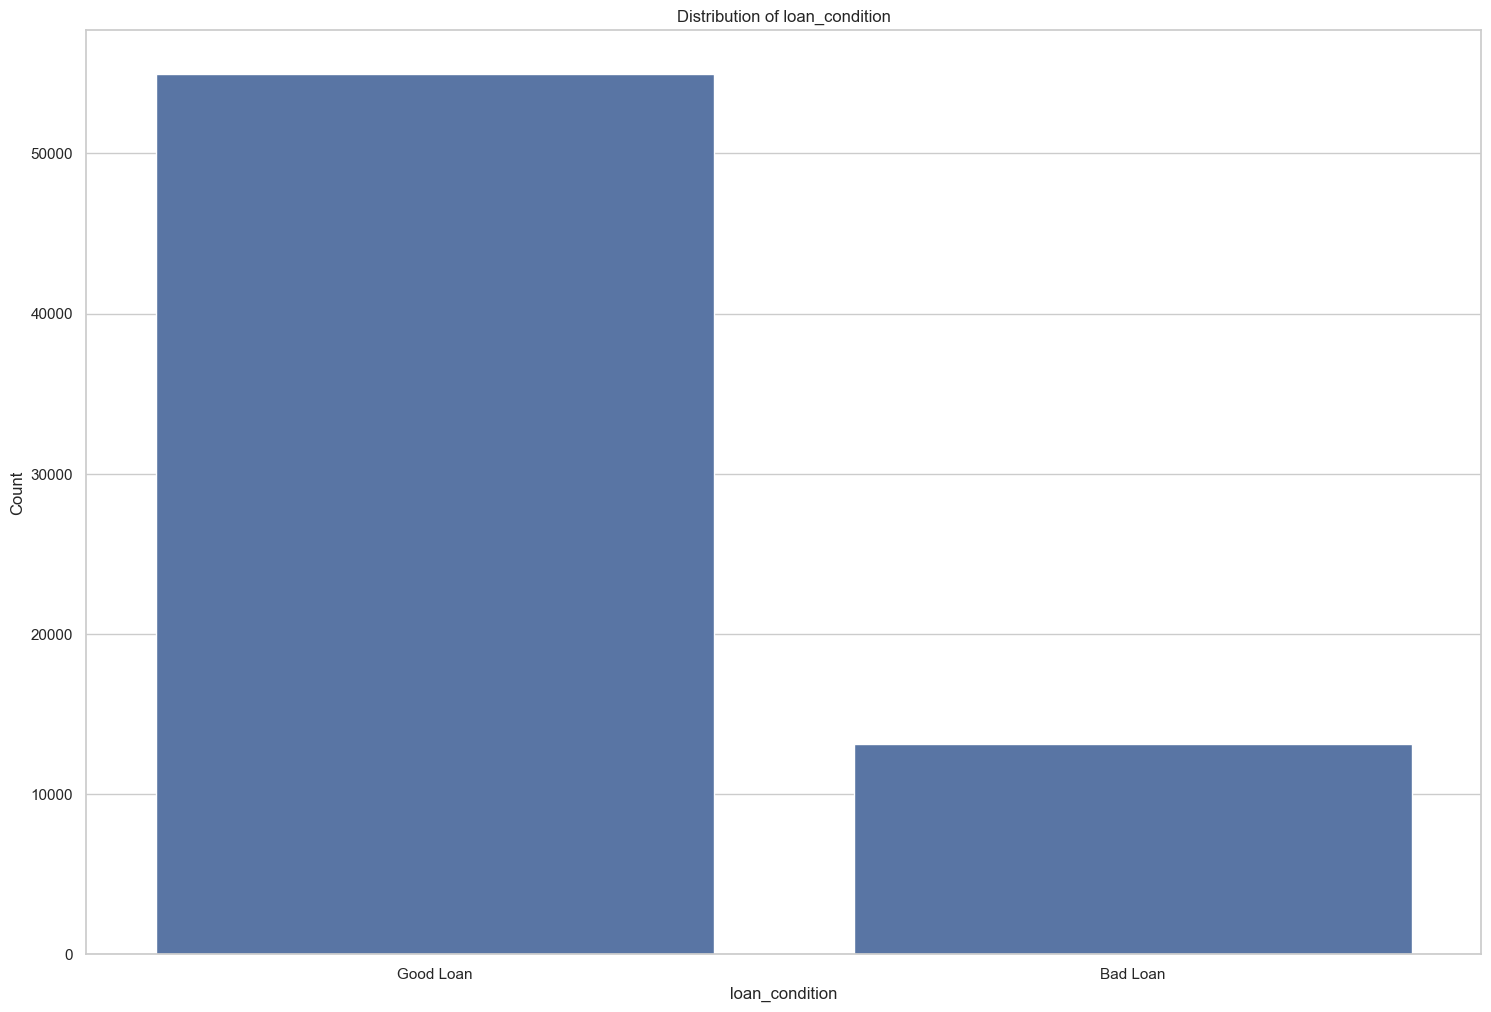

In [93]:
variable = "loan_condition" # @param ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'loan_condition_int', 'loan_condition', 'emp_length_int', 'region'] {allow-input: true}
plot_variable_distribution(EDA_df, variable)

In [94]:
def plot_2_variable_relationship(dataframe, x_variable, y_variable):
    if dataframe[x_variable].dtype != 'object' and dataframe[y_variable].dtype != 'object':
        # Two numerical variables, draw a scatter plot
        sns.scatterplot(x=x_variable, y=y_variable, data=dataframe)
        plt.xlabel(x_variable)
        plt.ylabel(y_variable)
        plt.title(f'Scatter Plot: {x_variable} vs. {y_variable}')
    elif dataframe[x_variable].dtype == 'object' and dataframe[y_variable].dtype == 'object':
        # Two categorical variables, draw a crosstab
        cross_tab = pd.crosstab(index=dataframe[x_variable], columns=dataframe[y_variable], normalize='columns') #Show column summary percentage
        sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
        plt.xlabel(y_variable)
        plt.ylabel(x_variable)
        plt.title(f'Cross Tabulation: {x_variable} vs. {y_variable}')
    elif (dataframe[x_variable].dtype != 'object' and dataframe[y_variable].dtype == 'object') or (dataframe[x_variable].dtype == 'object' and dataframe[y_variable].dtype != 'object'):
        # One categorical variable, one numerical variabl"e, draw a violin plot
        if dataframe[x_variable].dtype != 'object':
            x_variable, y_variable = y_variable, x_variable  # Swap the order of the variables and make sure Y is a numeric variable
        sns.violinplot(x=x_variable, y=y_variable, data=dataframe)
        plt.xlabel(x_variable)
        plt.ylabel(y_variable)
        plt.title(f'Violin Plot: {x_variable} vs. {y_variable}')
        sns.despine()
    else:
        print("Unsupported combination of variable types")

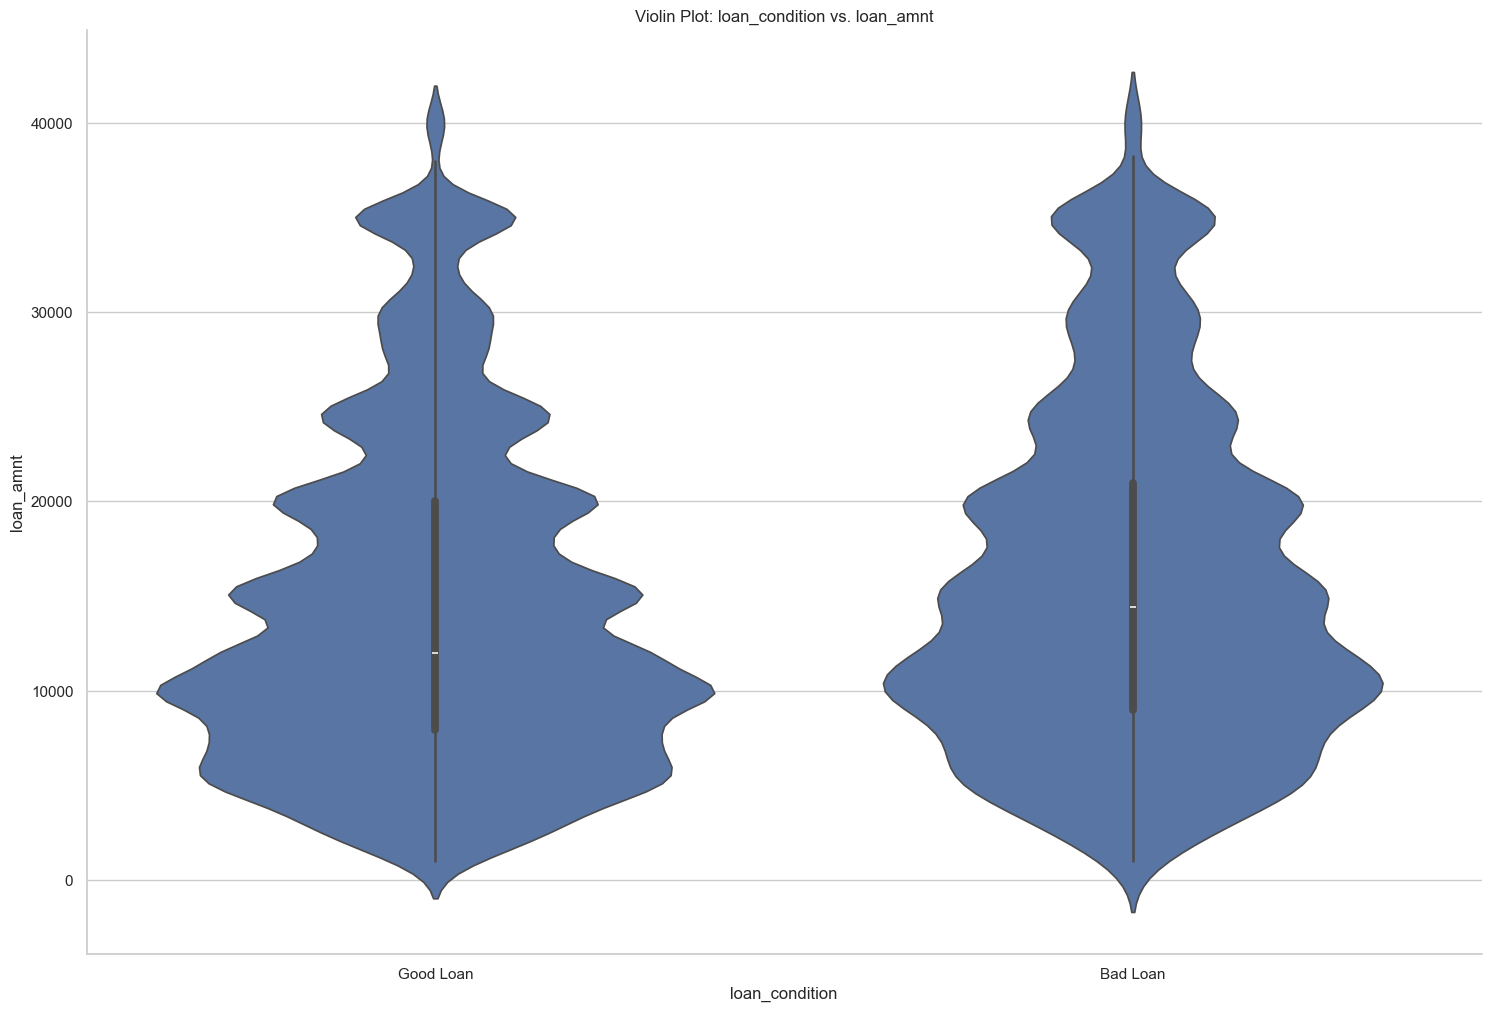

In [95]:
X = "loan_condition" 
Y = "loan_amnt"

plot_2_variable_relationship(EDA_df,X,Y) 

In [96]:
def plot_3_variable_relationship(dataframe, x1_variable, x2_variable, y_variable):
    num_types = ['int64', 'float64']

    if (dataframe[x1_variable].dtype == 'object' and
        dataframe[x2_variable].dtype == 'object' and
        dataframe[y_variable].dtype == 'object'):
        # Three categorical variables, draw a crosstab
        cross_tab = pd.crosstab(index=dataframe[x1_variable], columns=[dataframe[x2_variable], dataframe[y_variable]], normalize='columns')
        sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
        plt.xlabel(f'{x2_variable} - {y_variable}')
        plt.ylabel(x1_variable)
        plt.title(f'Cross Tabulation: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype == 'object' and
          dataframe[x2_variable].dtype == 'object' and
          dataframe[y_variable].dtype in num_types):
        # X1 and X2 are categorical, Y is a numerical variable, draw a violin plot or boxplot
        # Example: Drawing a Violin Plot
        sns.violinplot(x=x1_variable, y=y_variable, hue=x2_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(y_variable)
        plt.title(f'Violin Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype in num_types and
          dataframe[x2_variable].dtype in num_types and
          dataframe[y_variable].dtype == 'object'):
        # X1 and X2 are numerical variables, Y is a categorical variable, draw a box plot or violin plot
        # Example: Drawing a Violin Plot
        sns.boxplot(x=x1_variable, y=y_variable, hue=x2_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(y_variable)
        plt.title(f'Box Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype in num_types and
          dataframe[x2_variable].dtype in num_types and
          dataframe[y_variable].dtype in num_types):
        # Three numerical variables, draw a scatter plot
        sns.scatterplot(x=x1_variable, y=x2_variable, hue=y_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(x2_variable)
        plt.title(f'Scatter Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif ((dataframe[x1_variable].dtype == 'object' and dataframe[x2_variable].dtype in num_types) or
          (dataframe[x1_variable].dtype in num_types and dataframe[x2_variable].dtype == 'object')):
        # One of X1 and X2 is a categorical variable and the other is a numerical variable
        if dataframe[y_variable].dtype == 'object':
            # Y is a categorical variable, draw a boxplot or violin plot
            sns.boxplot(x=x1_variable, y=x2_variable, hue=y_variable, data=dataframe)
            plt.xlabel(x1_variable)
            plt.ylabel(x2_variable)
            plt.title(f'Box Plot: {x1_variable} vs. {x2_variable} with Color-Coded {y_variable}')
        elif dataframe[y_variable].dtype in num_types:
            # Y is a numerical variable, draw a box plot or violin plot
            sns.boxplot(x=x1_variable, y=x2_variable, data=dataframe)
            plt.xlabel(x1_variable)
            plt.ylabel(x2_variable)
            plt.title(f'Box Plot: {x1_variable} vs. {x2_variable}')
    else:
        print("Unsupported combination of variable types")


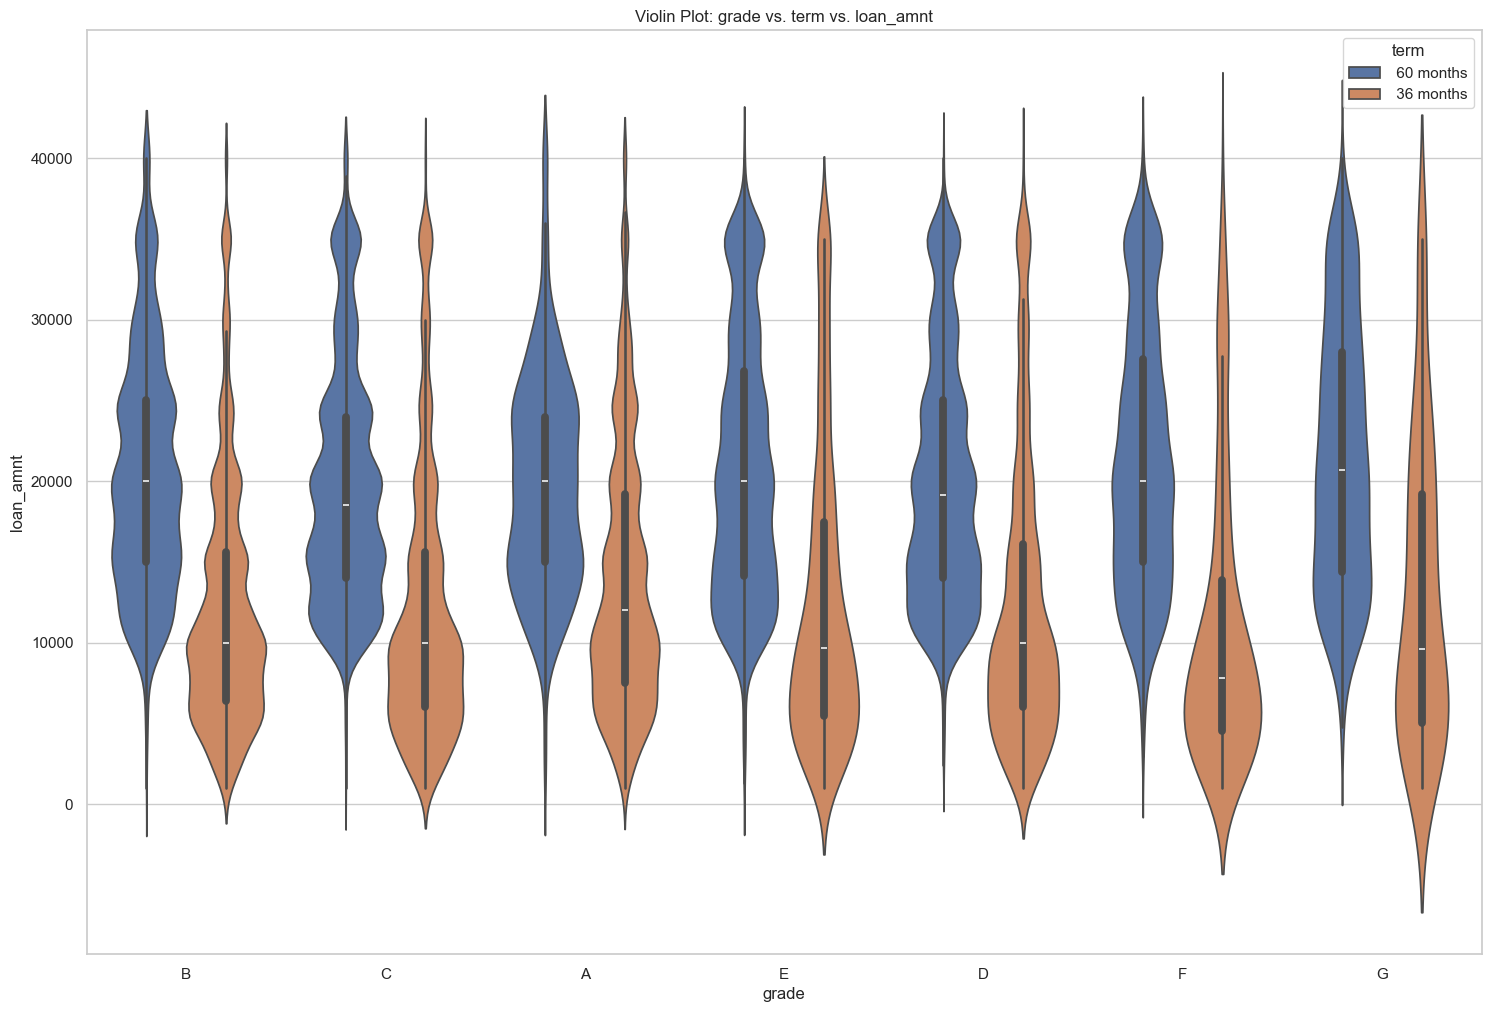

In [97]:
X1 = "grade"
X2 = "term" 
Y = "loan_amnt"

plot_3_variable_relationship(EDA_df,X1,X2,Y)

----

# Visualisations


In [100]:
data_for_tables = df.copy() # Remplacez par le nom de votre variable si nécessaire

# --- TABLEAU 1 : Statistiques Descriptives ---
# Sélection des colonnes numériques clés
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']
desc_stats = data_for_tables[num_cols].describe().transpose()

# Ajout de la médiane et formatage
desc_stats['median'] = data_for_tables[num_cols].median()
table_1 = desc_stats[['mean', 'median', 'std', 'min', 'max']]
table_1.columns = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']

print("--- TABLEAU 1 : SYNTHÈSE NUMÉRIQUE ---")
print(table_1.round(2))
print("\n")


# --- TABLEAU 2 : Analyse de la Variable Cible ---
target_counts = data_for_tables['loan_status'].value_counts()
target_perc = data_for_tables['loan_status'].value_counts(normalize=True) * 100

table_2 = pd.DataFrame({
    'Nombre': target_counts,
    'Proportion (%)': target_perc
})

print("--- TABLEAU 2 : DISTRIBUTION DU STATUT DES PRÊTS ---")
print(table_2.round(2))
print("\n")


# --- TABLEAU 3 : Risque par Grade ---
# Calcul du taux de défaut (Charged Off) par Grade
def calculate_default_rate(series):
    return (series == 'Charged Off').mean() * 100

risk_by_grade = data_for_tables.groupby('grade')['loan_status'].agg(
    Volume='count',
    Taux_de_defaut=calculate_default_rate
)

print("--- TABLEAU 3 : RISQUE PAR GRADE ---")
print(risk_by_grade.round(2))

--- TABLEAU 1 : SYNTHÈSE NUMÉRIQUE ---
             Moyenne   Médiane  Écart-type      Min          Max
loan_amnt   14663.08  12375.00     8767.88  1000.00     40000.00
int_rate       13.33     12.79        4.76     5.31        30.99
annual_inc  77416.80  65000.00    81436.43  6000.00  10999200.00
dti            18.18     17.73        8.41     0.00        49.78


--- TABLEAU 2 : DISTRIBUTION DU STATUT DES PRÊTS ---
                                                    Nombre  Proportion (%)
loan_status                                                               
Fully Paid                                           46585           68.41
Charged Off                                          11754           17.26
Current                                               8317           12.21
Late (31-120 days)                                     862            1.27
In Grace Period                                        319            0.47
Late (16-30 days)                                      1

In [101]:
# 4. Analyse Montant vs Condition (Numérique vs Catégorique)
print("--- TABLEAU 4 : Montant vs Condition ---")
print(df.groupby('loan_condition')['loan_amnt'].describe()[['mean', '50%', '75%']])

# 5. Analyse Taux vs Condition (Numérique vs Catégorique)
print("\n--- TABLEAU 5 : Taux d'intérêt vs Condition ---")
print(df.groupby('loan_condition')['int_rate'].mean())

# 6. Analyse Motif vs Condition (Catégorique vs Catégorique)
print("\n--- TABLEAU 6 : Risque par motif (Top 5) ---")
crosstab = pd.crosstab(df['purpose'], df['loan_condition'], normalize='index') * 100
print(crosstab.sort_values(by='Bad Loan', ascending=False).head(5))

--- TABLEAU 4 : Montant vs Condition ---
                        mean      50%      75%
loan_condition                                
Bad Loan        15773.536353  14400.0  21000.0
Good Loan       14397.697500  12000.0  20000.0

--- TABLEAU 5 : Taux d'intérêt vs Condition ---
loan_condition
Bad Loan     15.728146
Good Loan    12.754101
Name: int_rate, dtype: float64

--- TABLEAU 6 : Risque par motif (Top 5) ---
loan_condition     Bad Loan  Good Loan
purpose                               
renewable_energy  26.666667  73.333333
small_business    25.939850  74.060150
moving            24.503311  75.496689
house             22.797927  77.202073
educational       22.222222  77.777778


C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\2099443743.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




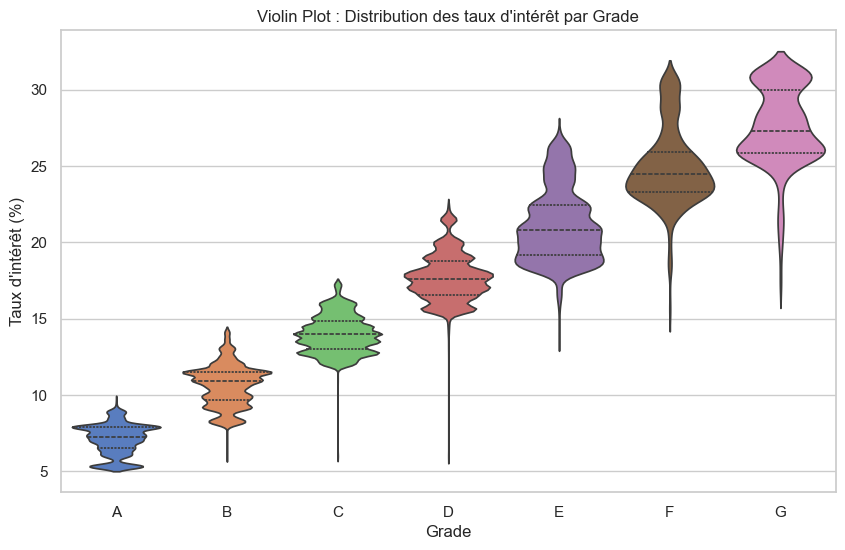

In [102]:
# 7. Distribution des taux d'intérêt par Grade (Violin Plot)

# Définir l'ordre exact souhaité pour l'axe X
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(10, 6))

# Ajout du paramètre "order"
sns.violinplot(
    x='grade', 
    y='int_rate', 
    data=df, 
    palette="muted", 
    inner="quartile",
    order=ordre_grades
)

plt.title("Violin Plot : Distribution des taux d'intérêt par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux d'intérêt (%)")
plt.show()

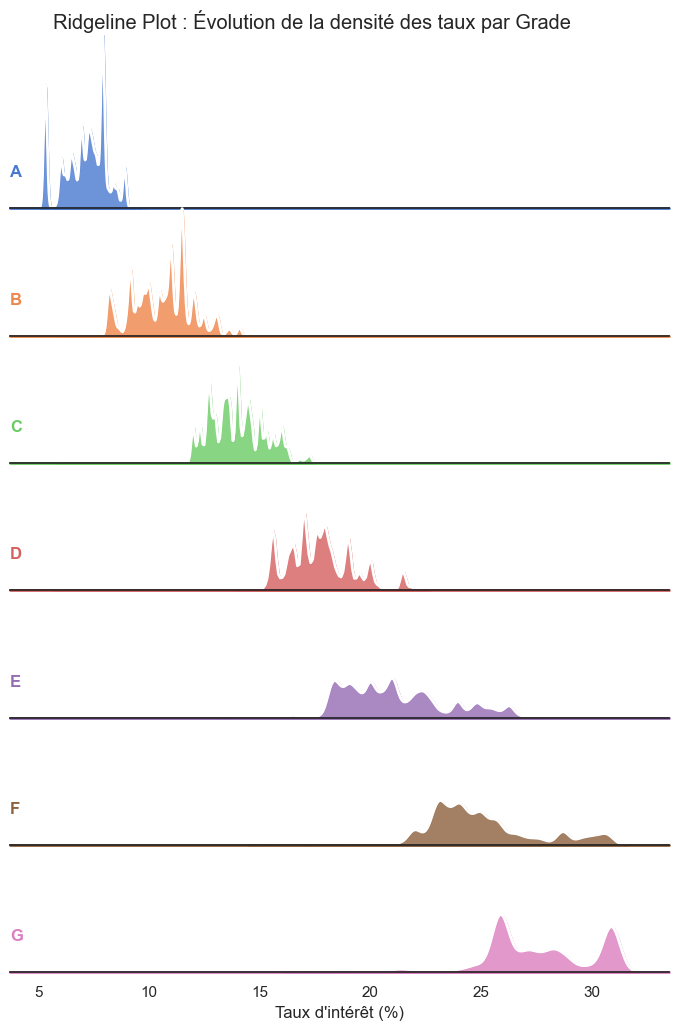

In [103]:
# 8. Évolution de la densité des taux par Grade (Ridgeline Plot)

# Configuration pour l'effet de chevauchement transparent
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# On définit l'ordre pour que la "montagne" descende de A à G
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Création de la grille
g = sns.FacetGrid(df, row="grade", hue="grade", aspect=5, height=1.5, palette="muted", 
                  row_order=ordre_grades, hue_order=ordre_grades)

# Dessin des courbes
g.map(sns.kdeplot, "int_rate", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
g.map(sns.kdeplot, "int_rate", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label_text(x, color, label):
    ax = plt.gca()
    # On positionne le texte tout à gauche (x=0) et un peu au-dessus de la ligne (y=0.2)
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

# On applique cette fonction à notre grille
g.map(label_text, "int_rate")

# Ajustement du chevauchement
g.fig.subplots_adjust(hspace=-0.3)

# Nettoyage des titres et de l'axe Y
g.set_titles("")
g.set(yticks=[], ylabel="")

# On retire uniquement l'axe de gauche
g.despine(left=True)

# Ajout du titre de l'axe X tout en bas
g.set_axis_labels("Taux d'intérêt (%)", "")

plt.suptitle("Ridgeline Plot : Évolution de la densité des taux par Grade", y=0.98)
plt.show()

# Restauration du thème classique pour la suite de votre notebook
sns.set_theme(style="whitegrid")

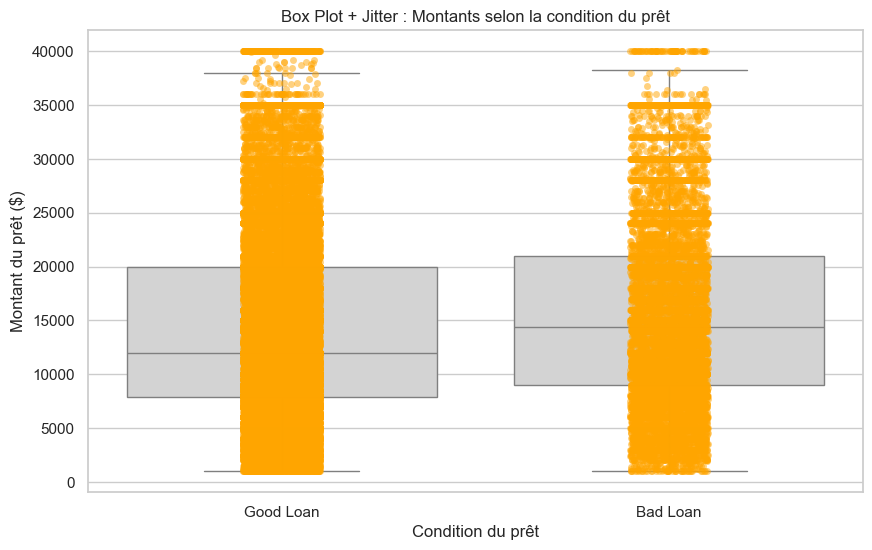

In [104]:
# 9. Montants selon la condition du prêt (Box Plot + Jitter)

plt.figure(figsize=(10, 6))
# On dessine la boîte grise en fond (sans les outliers pour plus de clarté)
sns.boxplot(x='loan_condition', y='loan_amnt', data=df, color="lightgray", showfliers=False)

# On ajoute les points individuels par dessus (le jitter éparpille les points horizontalement)
sns.stripplot(x='loan_condition', y='loan_amnt', data=df, color="orange", alpha=0.5, jitter=True)

plt.title("Box Plot + Jitter : Montants selon la condition du prêt")
plt.xlabel("Condition du prêt")
plt.ylabel("Montant du prêt ($)")
plt.show()

C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\226462640.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




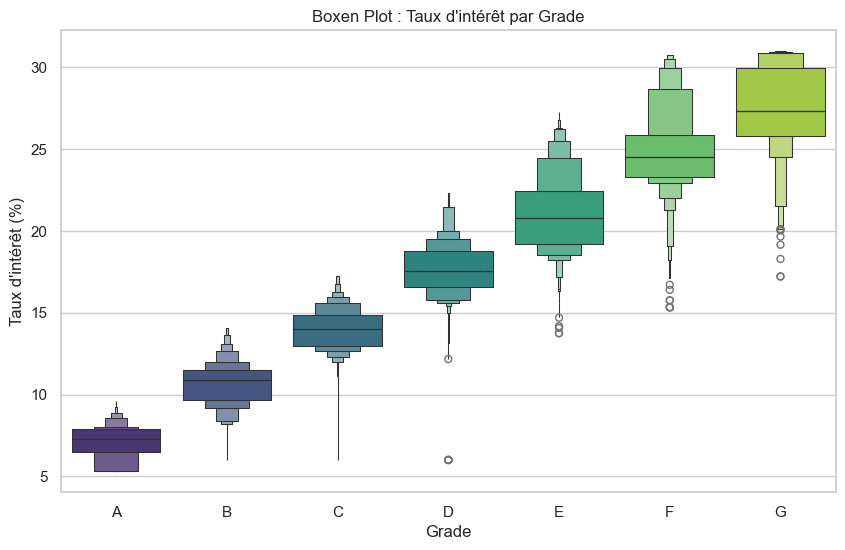

In [105]:
# 10. Taux d'intérêt par Grade (Boxen Plot)

# Définition de l'ordre logique des grades
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(10, 6))

# Ajout du paramètre order=ordre_grades
sns.boxenplot(
    x='grade', 
    y='int_rate', 
    data=df, 
    palette="viridis",
    order=ordre_grades
)

plt.title("Boxen Plot : Taux d'intérêt par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux d'intérêt (%)")
plt.show()

C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\640588722.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




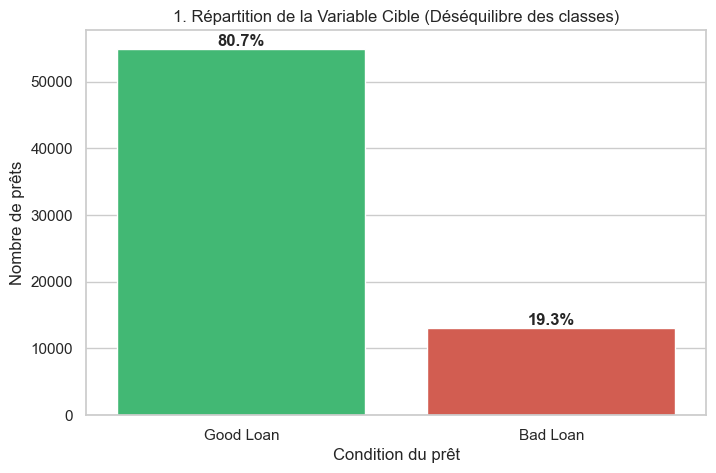

C:\Users\ebene\AppData\Local\Temp\ipykernel_16108\640588722.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




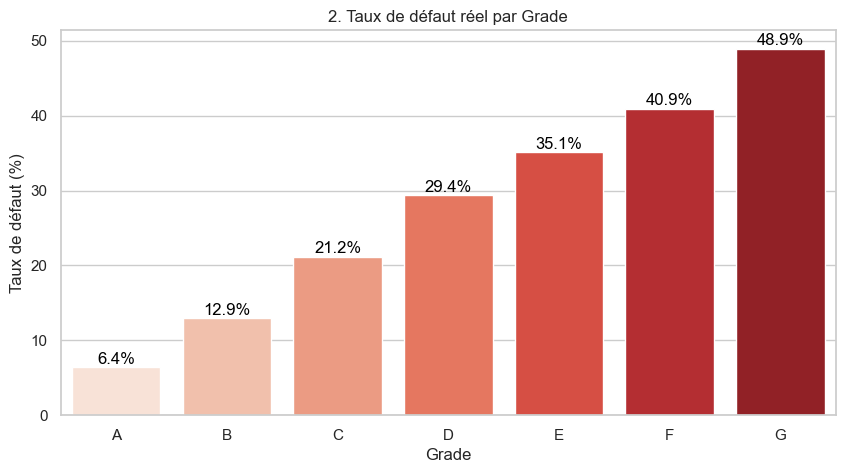

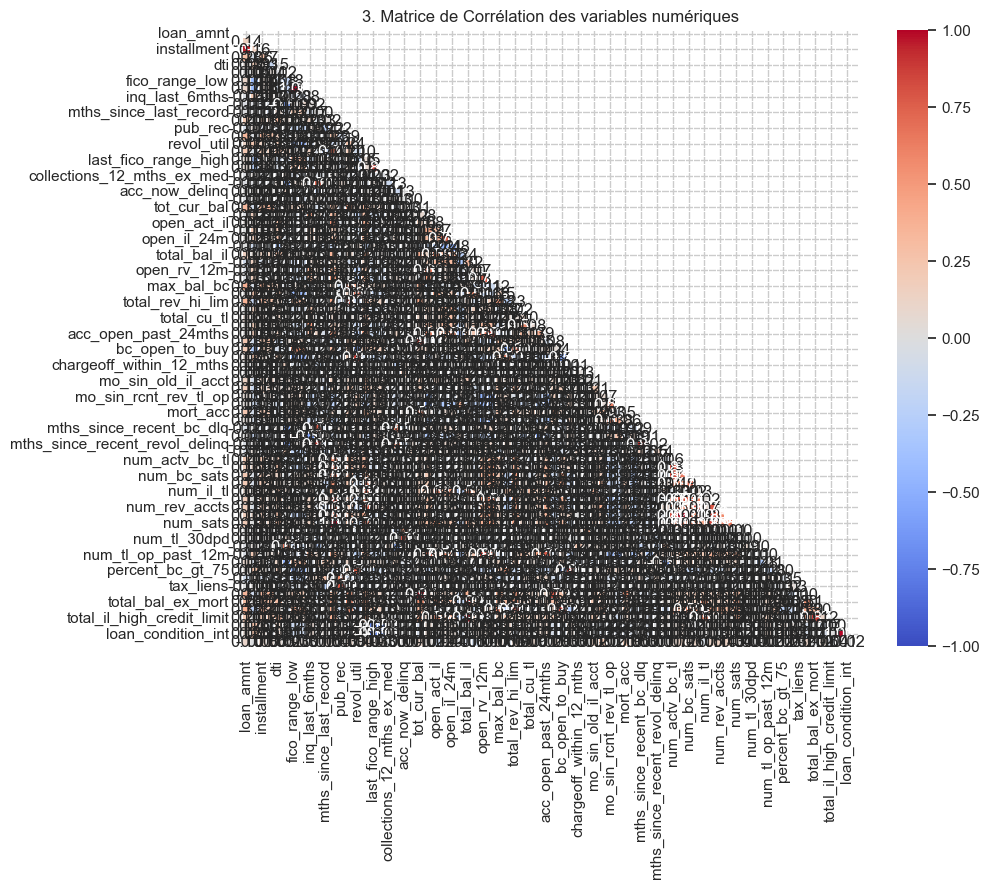

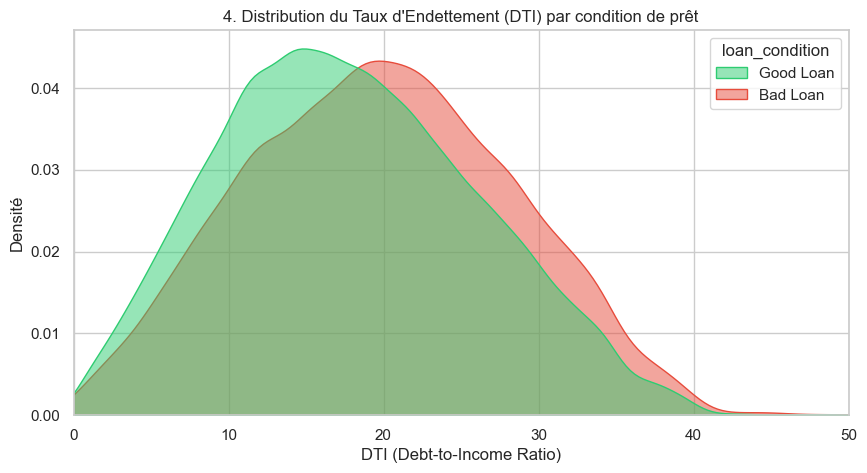

In [106]:
# Configuration générale pour l'esthétique
sns.set_theme(style="whitegrid")
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
palette_cible = {'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c'} # Vert et Rouge

# ==========================================
# 1. Répartition de la Variable Cible
# ==========================================
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='loan_condition', palette=palette_cible, order=['Good Loan', 'Bad Loan'])

# Ajout des pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.title("1. Répartition de la Variable Cible (Déséquilibre des classes)")
plt.xlabel("Condition du prêt")
plt.ylabel("Nombre de prêts")
plt.show()


# ==========================================
# 2. Taux de défaut réel par Grade
# ==========================================
plt.figure(figsize=(10, 5))
# Calcul du pourcentage de défauts pour chaque Grade
taux_defaut = df[df['loan_condition'] == 'Bad Loan'].groupby('grade').size() / df.groupby('grade').size() * 100
taux_defaut = taux_defaut.reset_index(name='taux')

sns.barplot(data=taux_defaut, x='grade', y='taux', palette="Reds", order=ordre_grades)
plt.title("2. Taux de défaut réel par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux de défaut (%)")

# Ajout de la valeur exacte au-dessus des barres
for index, row in taux_defaut.iterrows():
    plt.text(ordre_grades.index(row['grade']), row['taux'] + 0.5, f"{row['taux']:.1f}%", color='black', ha="center")
    
plt.show()


# ==========================================
# 3. Matrice de Corrélation
# ==========================================
plt.figure(figsize=(10, 8))
# Sélection uniquement des variables numériques (int, float)
df_num = df.select_dtypes(include=[np.number])

corr = df_num.corr()
# Création d'un masque pour cacher la moitié supérieure (redondante) du tableau
masque = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=masque, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("3. Matrice de Corrélation des variables numériques")
plt.show()


# ==========================================
# 4. Impact du DTI (Taux d'Endettement)
# ==========================================
plt.figure(figsize=(10, 5))
# Courbe de densité avec un remplissage (fill=True)
sns.kdeplot(data=df, x='dti', hue='loan_condition', common_norm=False, 
            fill=True, palette=palette_cible, alpha=0.5)

plt.title("4. Distribution du Taux d'Endettement (DTI) par condition de prêt")
plt.xlabel("DTI (Debt-to-Income Ratio)")
plt.ylabel("Densité")

# On limite généralement l'axe X à 50 ou 60 car le DTI a souvent des valeurs aberrantes très lointaines
plt.xlim(0, 50) 
plt.show()

<a name="Data-Cleaning"></a>
# Data Cleaning

This part includes:


*   Removing Exclusions
*   Missing Value Imputation
*   Removing Outliers

<a name="Removing-exclusions"></a>
## Removing Exclusions


**Delete variables with more than 80% missing values**

There are a lot of columns which have huge chunk of data missing. These columns are not necessary for our analysis. The following part will drop any columns where 20% or more data is missing, which means only columns whose number of non-null values is at least 80% of the total number of rows in the dataset will be retained.

In [107]:
drop_df = df


In [108]:
def get_missing_value_stats(input_df):
    df_null = pd.DataFrame({
        'Missing Count': input_df.isnull().sum(),
        'Missing Percent': 100 * input_df.isnull().sum() / len(input_df),
        'Type': input_df.dtypes
    })
    missing_values = df_null[df_null['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False) #改
    return missing_values

def get_value_stats(input_df):
    df_null = pd.DataFrame({
        '#Count': input_df.notna().sum(),
        '%Populated': 100 * input_df.notna().sum() / len(input_df),
        '#Unique Values':input_df.nunique(),
        'Most Common Value': input_df.mode().iloc[0],
        'Type': input_df.dtypes
    })

    missing_values = df_null[df_null['#Count'] > 0].sort_values(by='#Count', ascending=False)

    return missing_values

# Finding the the count and percentage of values that are missing.
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
mths_since_last_record,56515,82.991909,float64
mths_since_recent_bc_dlq,51680,75.891743,float64
mths_since_last_major_derog,49980,73.395304,float64
mths_since_recent_revol_delinq,44998,66.079269,float64
il_util,42341,62.177482,float64
mths_since_rcnt_il,39124,57.453339,float64
all_util,38328,56.284418,float64
open_il_24m,38327,56.282949,float64
total_bal_il,38327,56.282949,float64
open_rv_12m,38327,56.282949,float64


In [109]:
#drop any columns where over a certain percentage is missing
drop_df = drop_df.dropna(axis=1, thresh=int(0.20*len(drop_df)))
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
mths_since_recent_bc_dlq,51680,75.891743,float64
mths_since_last_major_derog,49980,73.395304,float64
mths_since_recent_revol_delinq,44998,66.079269,float64
il_util,42341,62.177482,float64
mths_since_rcnt_il,39124,57.453339,float64
all_util,38328,56.284418,float64
open_il_24m,38327,56.282949,float64
total_bal_il,38327,56.282949,float64
open_rv_12m,38327,56.282949,float64
open_il_12m,38327,56.282949,float64


<a name="Missing-Value-Imputation"></a>
## Missing Value Imputation


<table>
  <tr><th>index</th><th>Count</th><th>Percent</th><th>Type</th><th>Imputation method</th></tr>
  <tr><td>tot_coll_amt</td><td>66689</td><td>24.06</td><td>float64</td><td>0</td></tr>
  <tr><td>total_rev_hi_lim</td><td>66689</td><td>24.06</td><td>float64</td><td>0</td></tr>
  <tr><td>tot_cur_bal</td><td>66689</td><td>24.06</td><td>float64</td><td>0</td></tr>
  <tr><td>emp_length_int</td><td>11101</td><td>4.005</td><td>float64</td><td>median</td></tr>
  <tr><td>last_pymnt_d</td><td>921</td><td>0.332</td><td>object</td><td>mode</td></tr>
  <tr><td>revol_util</td><td>253</td><td>0.091</td><td>float64</td><td></td></tr>
  <tr><td>collections_12_mths_ex_med</td><td>145</td><td>0.052</td><td>float64</td><td></td></tr>
  <tr><td>pub_rec</td><td>29</td><td>0.0104</td><td>float64</td><td>median</td></tr>
  <tr><td>delinq_2yrs</td><td>29</td><td>0.0104</td><td>float64</td><td>mean</td></tr>
  <tr><td>last_credit_pull_d</td><td>24</td><td>0.0086</td><td>object</td><td>mode</td></tr>
  <tr><td>annual_income</td><td>4</td><td>0.00144</td><td>float64</td><td>mean</td></tr>
  <tr><td>income_category</td><td>4</td><td>0.00144</td><td>object</td><td>mode</td></tr>
</table>

In [110]:
fillna_df = drop_df.copy()

# # for object variables - Get the mode of next payment date and last payment date and the last date credit amount was pulled
# for column in ["last_pymnt_d", "last_credit_pull_d"]:  #, 'income_category'
#     fillna_df[column] = fillna_df.groupby("region")[column].transform(lambda x: x.fillna(x.mode()))

# for numerical variables
# Get the mode on the number of accounts in which the client is delinquent
fillna_df["pub_rec"] = fillna_df.groupby("region")["pub_rec"].transform(lambda x: x.fillna(x.median()))
# Get the mode of the total number of credit lines the borrower has
fillna_df["total_acc"] = fillna_df.groupby("region")["total_acc"].transform(lambda x: x.fillna(x.median()))

fillna_df["emp_length_int"] = fillna_df.groupby("region")["emp_length_int"].transform(lambda x: x.fillna(x.median()))

# Get the mean of the annual income depending on the region the client is located.
fillna_df["annual_inc"] = fillna_df.groupby("region")["annual_inc"].transform(lambda x: x.fillna(x.mean()))
# Mode of credit delinquencies in the past two years.
fillna_df["delinq_2yrs"] = fillna_df.groupby("region")["delinq_2yrs"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# # for other, fill in with zero
# fillna_df.fillna(0, inplace=True)
# fillna_df.isnull().sum().max() # Maximum number of nulls.

In [112]:
# Identifier et remplir les colonnes numériques avec le chiffre 0
cols_num = fillna_df.select_dtypes(include=['number']).columns
fillna_df[cols_num] = fillna_df[cols_num].fillna(0)

# Identifier et remplir les colonnes de texte avec le texte "0" (ou "Inconnu", "Missing", etc.)
cols_str = fillna_df.select_dtypes(include=['object']).columns
fillna_df[cols_str] = fillna_df[cols_str].fillna("0")

# Vérifier le nombre maximum de valeurs nulles restantes
fillna_df.isnull().sum().max()

np.int64(0)

In [113]:
len(fillna_df['loan_condition_int'])
# Loan Ratios (Imbalanced classes)
fillna_df['loan_condition_int'].value_counts()/len(fillna_df['loan_condition_int']) * 100

loan_condition_int
0    80.711338
1    19.288662
Name: count, dtype: float64

<a name="Removing-Outliers"></a>
## Removing Outliers

Custom thresholds were used to remove outliers
(3-sigma method did not work well)

In [114]:
#Custom thresholds
RemoveOutlier_df = fillna_df.copy()
print("Dataset before removing outlier:",RemoveOutlier_df.shape)
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['annual_inc'] <= 250000]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['dti'] <= 50]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['open_acc'] <= 40]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['total_acc'] <= 80]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_util'] <= 120]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_bal'] <= 250000]
RemoveOutlier_df.reset_index(drop=True, inplace=True)
print("Dataset after removing outlier:",RemoveOutlier_df.shape)

RemoveOutlier_df.head().transpose()

Dataset before removing outlier: (68097, 90)
Dataset after removing outlier: (67230, 90)


,0,1,2,3,4
loan_amnt,32000.0,9600.0,4000.0,6025.0,20000.0
term,60 months,36 months,36 months,36 months,36 months
int_rate,10.49,12.99,6.68,10.91,9.49
installment,687.65,323.42,122.93,197.0,640.57
grade,B,C,A,B,B
...,...,...,...,...,...
target_risk,0.0,0.0,0.0,0.0,0.0
loan_condition_int,0,0,0,0,0
loan_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan
emp_length_int,10.0,6.0,4.0,10.0,10.0


<a name="Correlation-Analysis"></a>
# Correlation Analysis

Correlation analysis was performed on the variables to assess their importance and relationship to the target variable y. This provided insights into the most relevant variables for predicting good vs bad loans.

For the correlation analysis, categorical variables were label encoded to enable numeric correlation values to be calculated. While this encoding can introduce artificial numerical relationships, it provided a convenient quick view of variable importance.

For the actual model building later on, more appropriate encodings like target encoding were used for the categorical variables.

In [115]:
target_col = target_variable = "loan_condition_int"

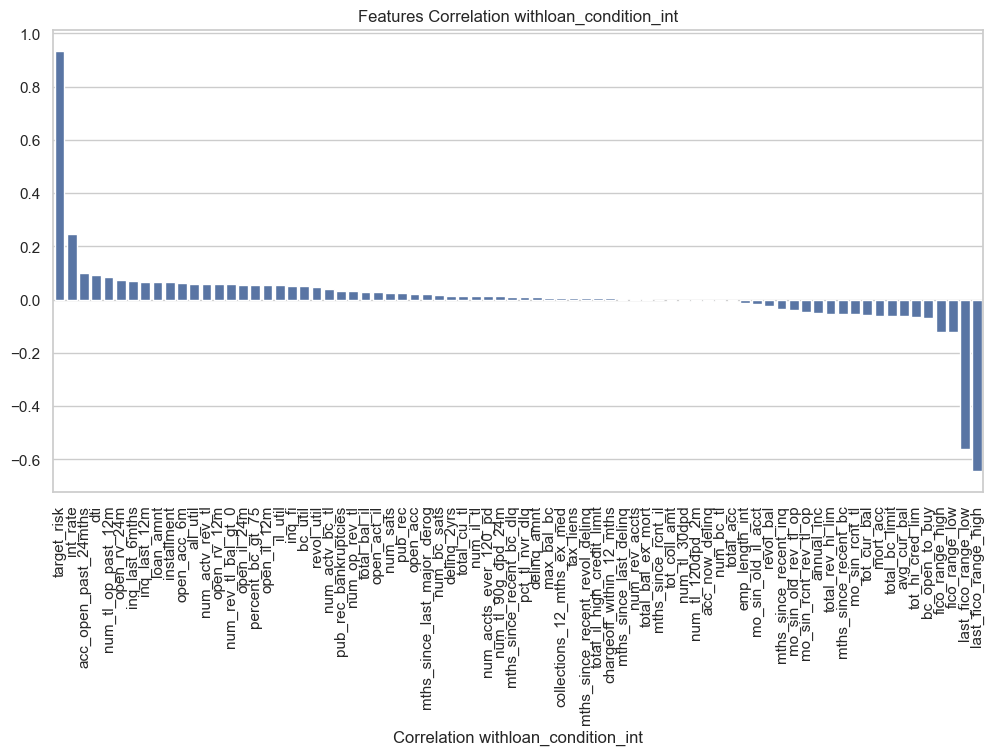

target_risk             0.934907
int_rate                0.246672
acc_open_past_24mths    0.100940
dti                     0.091626
num_tl_op_past_12m      0.086299
                          ...   
bc_open_to_buy         -0.070191
fico_range_high        -0.121747
fico_range_low         -0.121749
last_fico_range_low    -0.559994
last_fico_range_high   -0.642311
Name: loan_condition_int, Length: 76, dtype: float64


In [116]:
corr_df = RemoveOutlier_df.copy() 

# correlation with y
correlation_with_loan_condition = corr_df.select_dtypes(include=['int64', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, orient='v')
plt.xlabel('Correlation with{}'.format(target_variable))
plt.title('Features Correlation with{}'.format(target_variable))
plt.xticks(rotation=90)
plt.show()
print(sorted_correlation)

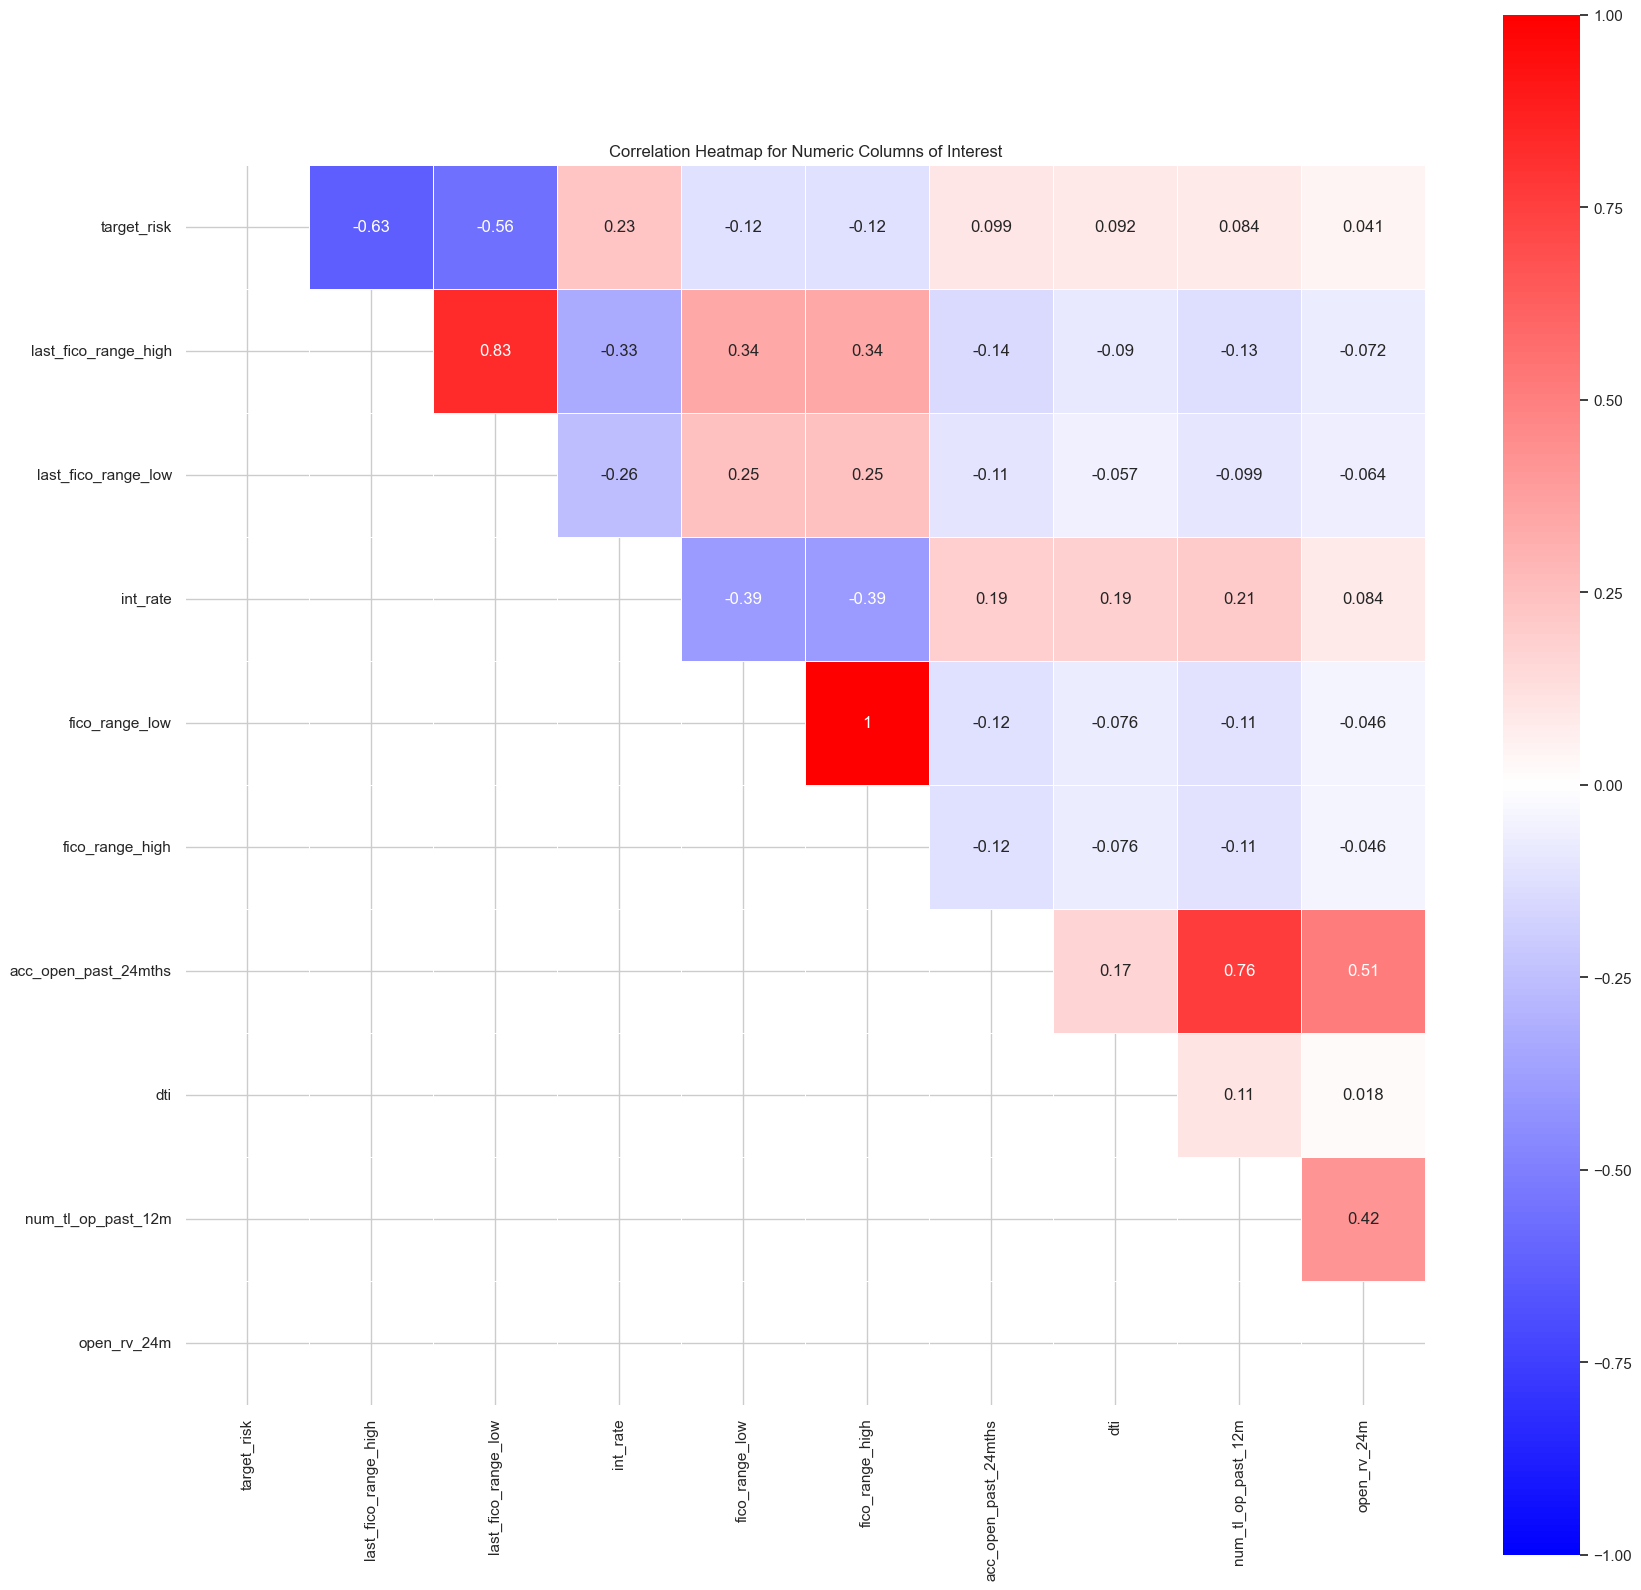

In [117]:
# Select the variables with the highest correlation with the dependent variable and explore the correlation between them
top_variables = sorted_correlation.abs().nlargest(10).index.tolist()

plt.figure(figsize=(20, 20))
correlation_matrix = RemoveOutlier_df[top_variables].corr()
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='bwr', vmin=-1, vmax=1, square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap for Numeric Columns of Interest')
plt.show()

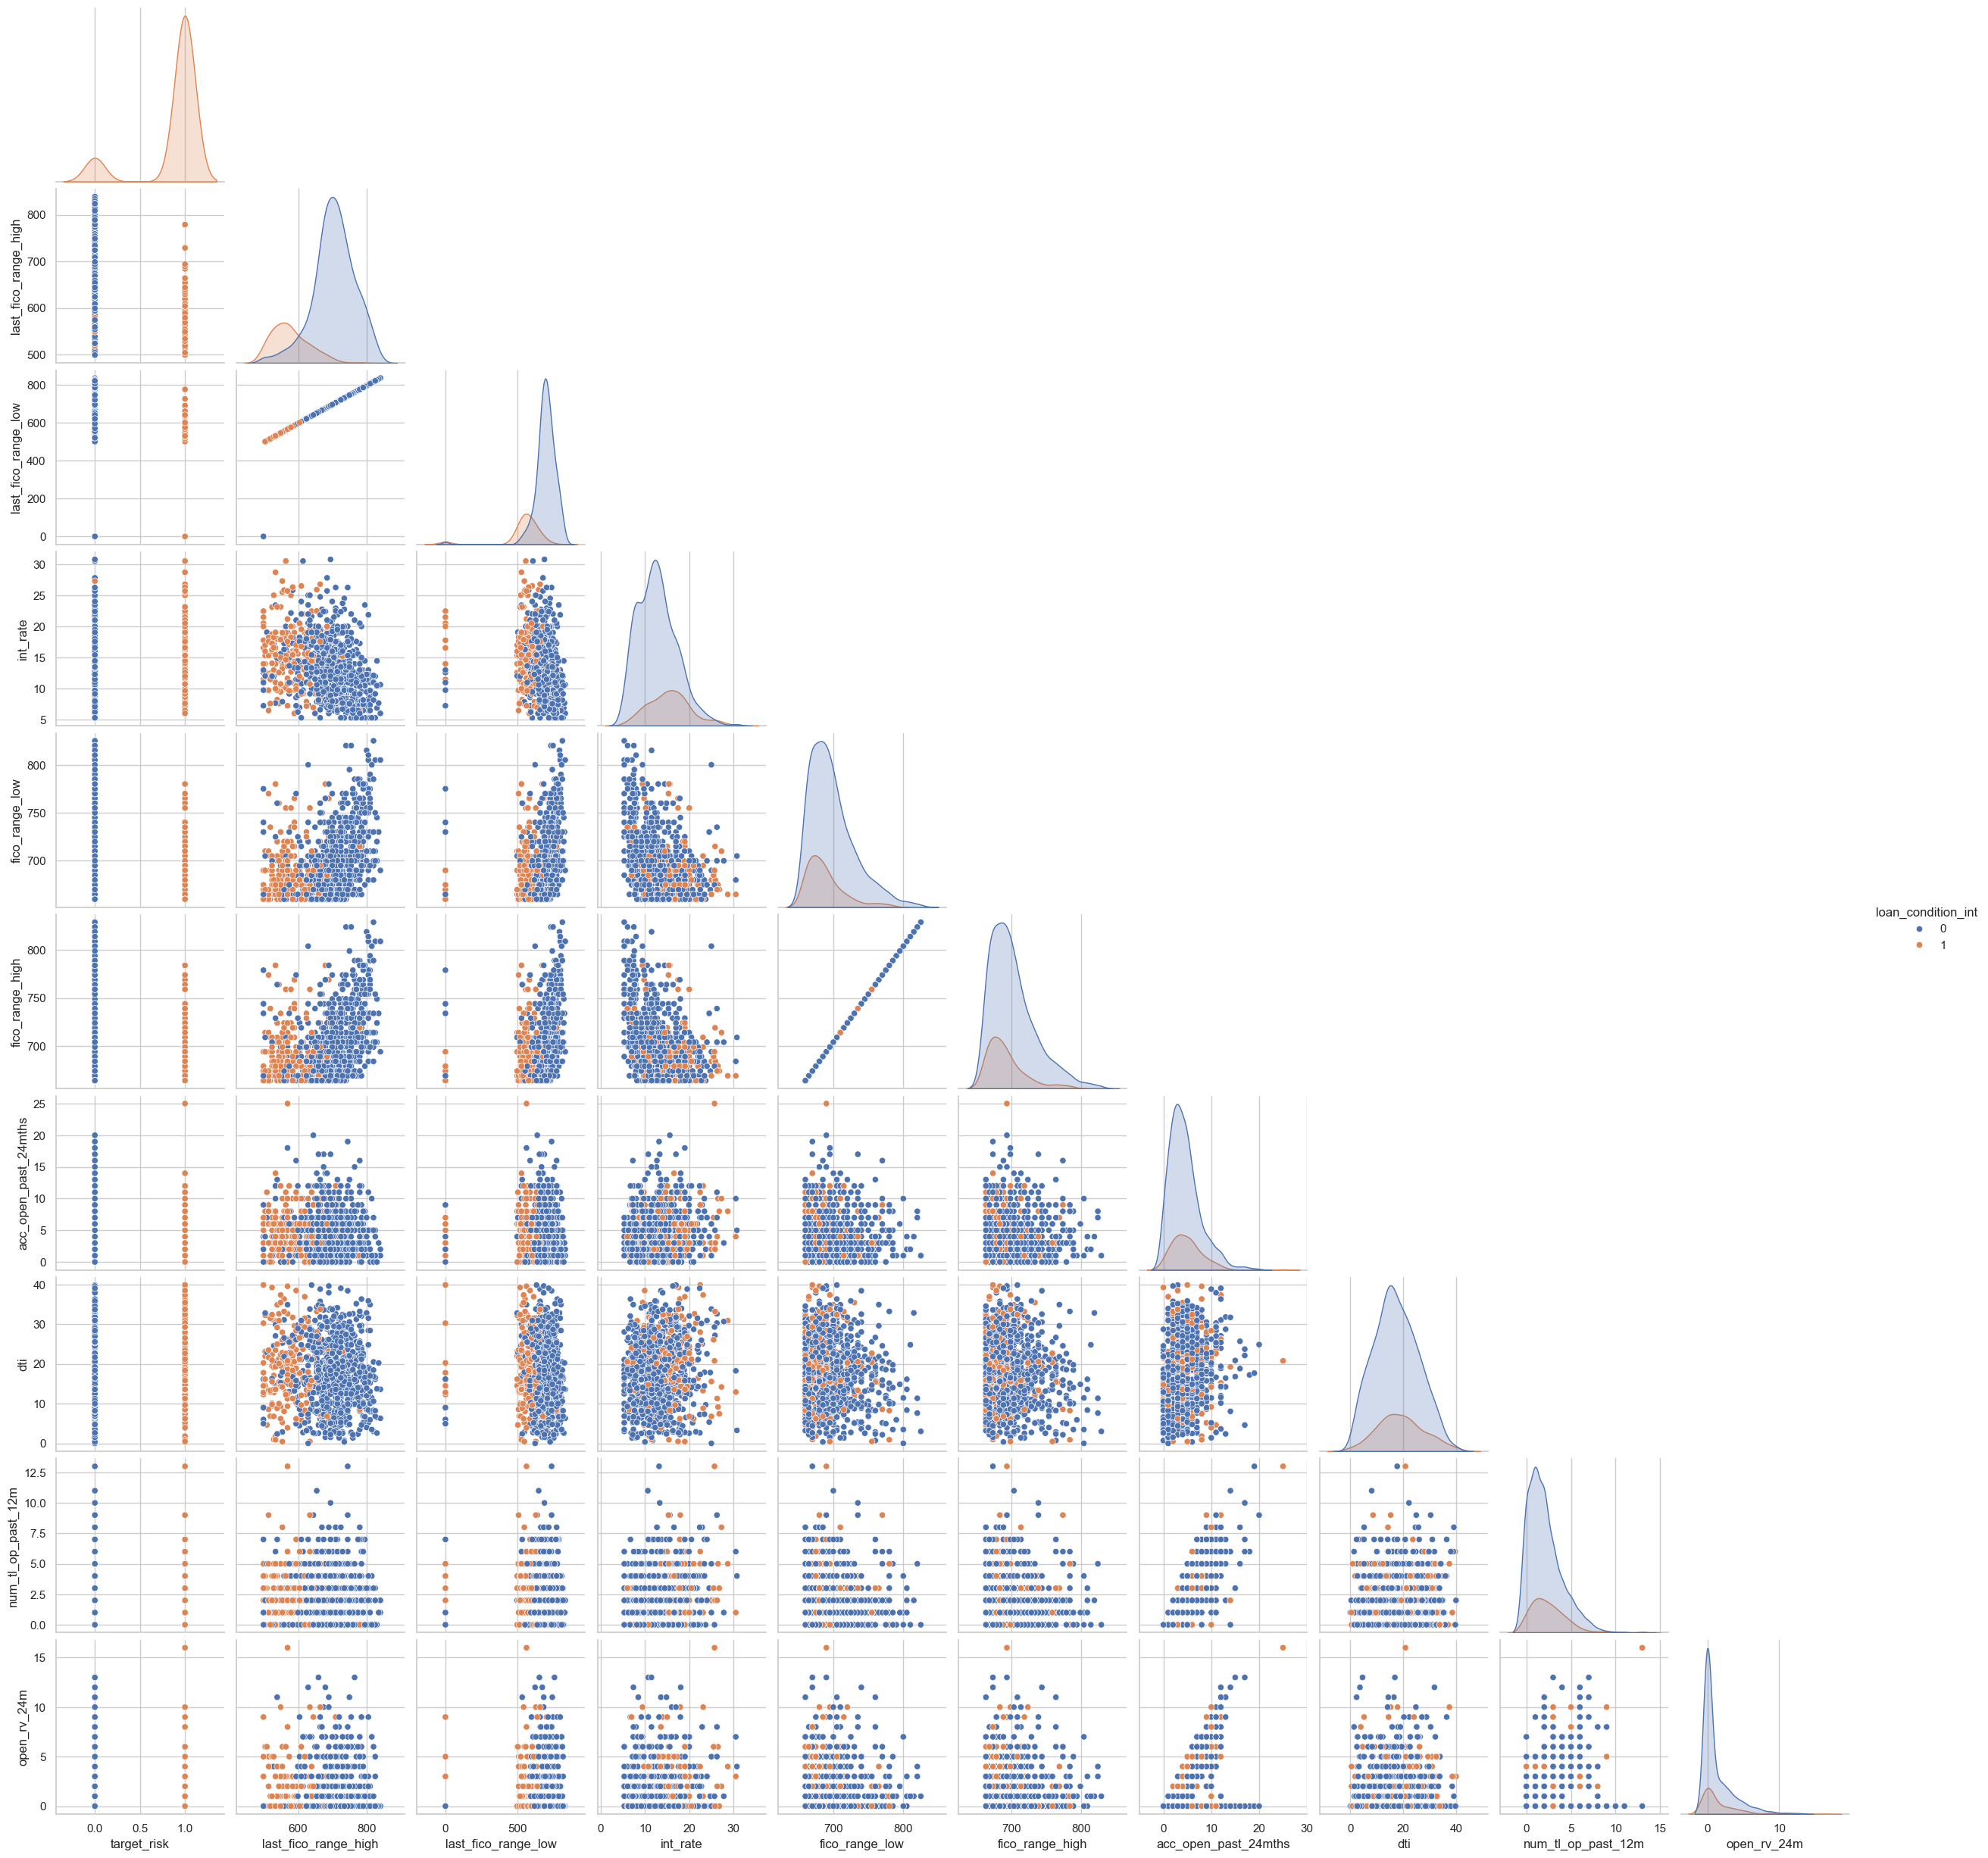

In [118]:
# # Further, explore the specific distribution of the relationship between variables under the action of the dependent variable loan_condition_int
# # This runs a bit slowly, so run with caution
sample_corr_df = corr_df[top_variables + [target_variable]].sample(n=1000, random_state=42)
sns.pairplot(sample_corr_df,hue=target_variable, diag_kind='kde',corner=True)

In [119]:
# Sauvegardes en vue de la partie suivante

# Données

RemoveOutlier_df.to_parquet("DATA/cleaned_data_for_modeling.parquet")

print("Données nettoyées sauvegardées pour la phase de feature engineering.")

# Cible

with open("CONFIG/target_config.txt", "w") as f:
    f.write(target_col)

print(f"Configuration sauvegardée : la cible est '{target_col}'")

Données nettoyées sauvegardées pour la phase de feature engineering.
Configuration sauvegardée : la cible est 'loan_condition_int'


----
